## Desarrollo tarea HW Sesión 6

Felipe López Vergara

In [58]:
import yfinance as yf
import numpy as np
import pandas as pd
from pandas_datareader import data as pdr
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from arch import arch_model
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import t
from scipy.stats import chi2_contingency
import scipy.stats as stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import gower
from kmodes.kprototypes import KPrototypes
import itertools
import hdbscan
import prince
import warnings
warnings.filterwarnings("ignore")

## 1. Aprendizaje no Supervisado — Segmentación de Clientes para Otorgamiento de Tarjetas de Crédito

Considere el dataset creditSIM.xlsx que contiene información de clientes de un banco. El objetivo es construir perfiles o clusters de clientes de modo que, mediante estrategias de campañas de marketing, se pueda decidir a quién otorgar tarjetas de crédito. El dataset contiene las siguientes variables:

ID: Número de cliente.
AgnosDirec: Años que el cliente lleva viviendo en la misma dirección.
AgnosEmpleo: Años de antigüedad del cliente en el empleo.
DeudaExt: Deuda del cliente externa al banco.
DeudaInt: Deuda del cliente en el banco (por ejemplo, otros créditos).
Edad: Edad del cliente.
Ingreso/Ingreso2: Ingreso del cliente (recopilados de dos fuentes diferentes).
Nacionalidad: Nacionalidad del cliente.
NivelEdu: Nivel educacional del cliente.
VarObj: Variable objetivo — si el cliente cae en bancarrota al recibir el crédito (S) o no (N).

⚠️ Regla del ejercicio: VarObj no puede usarse como input del proceso de clustering (sería leakage, ya que en producción no se conoce el comportamiento futuro del cliente al momento de aprobar la tarjeta). Su único uso permitido es como variable de validación externa en la Sección 1.6.

### 1.1 Auditoría y Preprocesamiento de Datos

**(a)** Reporte tipos de datos, cardinalidad de las variables categóricas, porcentaje de valores nulos por columna y estadística descriptiva de las variables numéricas. Justifique una estrategia de imputación (o eliminación) para los nulos encontrados — no use dropna() sin antes cuantificar cuánta información se pierde.

In [2]:
#Cargando archivo 

df = pd.read_excel("C:/Users/jeloy/Desktop/Magíster en Finanzas/Data Science/creditSIM.xlsx")
df.head()

,ID,AgnosDirec,AgnosEmpleo,DeudaExt,DeudaInt,Edad,Ingreso,Ingreso2,Nacionalidad,NivelEdu,VarObj
0,100001,4.0,2.0,9561.984843,7660.036317,40.0,64117.447797,44473.097916,N,SupInc,S
1,100002,28.0,25.0,11985.886924,6872.030508,49.0,124062.085998,84958.101814,N,Med,N
2,100003,2.0,3.0,1028.356328,1075.598877,38.0,32010.884862,27638.818281,N,SupCom,N
3,100004,11.0,14.0,10974.303210,2377.430575,43.0,172337.436327,125056.572446,N,Bas,N
4,100005,3.0,1.0,842.807194,1142.827425,33.0,25937.760762,23755.321327,N,SupInc,S


In [8]:
# Reporte de Variables (Tipos, cardinalidad, nulos y porcentaje de nulos)

reporte_variables = pd.DataFrame(
    {
        "Tipo_Dato": df.dtypes,
        "Valores_Nulos": df.isnull().sum(),
        "Porcentaje_Nulos (%)": (df.isnull().sum() / len(df)) * 100,
        "Valores_Unicos": df.nunique(),
    }
)

# Filtrar cardinalidad específicamente para variables categóricas / texto
cat_cols = df.select_dtypes(include=["object", "category"]).columns
reporte_variables["Cardinalidad_Categorica"] = np.nan
reporte_variables.loc[cat_cols, "Cardinalidad_Categorica"] = df[
    cat_cols
].nunique()

print("--- 1. REPORTE DE VARIABLES Y VALORES NULOS ---")
print(reporte_variables.round(2))
print("\n" + "=" * 80 + "\n")

--- 1. REPORTE DE VARIABLES Y VALORES NULOS ---
             Tipo_Dato  Valores_Nulos  Porcentaje_Nulos (%)  Valores_Unicos  \
ID               int64              0                  0.00            3000   
AgnosDirec     float64              1                  0.03              45   
AgnosEmpleo    float64              2                  0.07              41   
DeudaExt       float64              1                  0.03            2999   
DeudaInt       float64              4                  0.13            2996   
Edad           float64              2                  0.07              54   
Ingreso        float64              2                  0.07            2998   
Ingreso2       float64              0                  0.00            2999   
Nacionalidad       str              0                  0.00               1   
NivelEdu           str              0                  0.00               5   
VarObj             str              0                  0.00               2   

   

In [9]:
# Estadística Descriptiva variables numéricas

num_cols = df.select_dtypes(include=[np.number]).columns

print("--- 2. ESTADÍSTICA DESCRIPTIVA (VARIABLES NUMÉRICAS) ---")
estadistica_num = df[num_cols].describe().T
estadistica_num["mediana"] = df[num_cols].median()  # P50 / Mediana explícita
print(estadistica_num.round(2))
print("\n" + "=" * 80 + "\n")

--- 2. ESTADÍSTICA DESCRIPTIVA (VARIABLES NUMÉRICAS) ---
              count       mean       std        min        25%        50%  \
ID           3000.0  101500.50    866.17  100001.00  100750.75  101500.50   
AgnosDirec   2999.0       7.09      6.96       0.00       2.00       5.00   
AgnosEmpleo  2998.0       7.15      6.65       0.00       2.00       5.00   
DeudaExt     2999.0    4531.01   7084.78      21.55    1110.24    2278.66   
DeudaInt     2996.0    2275.68   5409.79       8.30     416.04     958.28   
Edad         2998.0      37.66     36.63      18.00      29.00      36.50   
Ingreso      2998.0   62567.74  49385.68  -13123.60   30282.68   49516.13   
Ingreso2     3000.0   52152.67  42246.04   -9723.72   25109.56   40632.27   

                   75%        max    mediana  
ID           102250.25  103000.00  101500.50  
AgnosDirec       10.00      61.00       5.00  
AgnosEmpleo      10.00      47.00       5.00  
DeudaExt       5093.77  123939.24    2278.66  
DeudaInt      

In [10]:
# Cuantificación filas a eliminar 

filas_totales = len(df)
filas_sin_nulos = len(df.dropna())
filas_perdidas = filas_totales - filas_sin_nulos
porcentaje_perdido = (filas_perdidas / filas_totales) * 100

print("--- Cuantificación de filas eliminadas al utilizar dropna() ---")
print(f"Filas totales originales: {filas_totales}")
print(f"Filas restantes si se usa dropna(): {filas_sin_nulos}")
print(f"Filas que se perderían: {filas_perdidas} ({porcentaje_perdido:.2f}% del dataset)")

--- Cuantificación de filas eliminadas al utilizar dropna() ---
Filas totales originales: 3000
Filas restantes si se usa dropna(): 2988
Filas que se perderían: 12 (0.40% del dataset)


Calculé cuántos datos se perdín al borrar las filas incompletas con dropna(), y fue solo el 0.40% del total (12 filas). Como es una cantidad muy pequeña que no afecta la calidad ni los resultados del análisis, por lo que decidí eliminar esas filas.

In [11]:
df = df.dropna()
print(len(df))

2988


**(b)** Analice Ingreso e Ingreso2: ¿son consistentes entre sí (correlación, diferencias sistemáticas)? Decida y justifique si usará una, ambas, un promedio, o una variable derivada (por ejemplo, la discrepancia entre ambas como proxy de riesgo de fraude declarativo).

In [12]:
# Métricas de Correlación y Diferencia

# Filtrar registros donde ambas variables estén presentes para comparar
df_ingresos = df[["Ingreso", "Ingreso2"]]

# Correlaciones (Pearson para lineal, Spearman para rangos/outliers)
corr_pearson = df_ingresos["Ingreso"].corr(df_ingresos["Ingreso2"], method="pearson")
corr_spearman = df_ingresos["Ingreso"].corr(df_ingresos["Ingreso2"], method="spearman")

# Diferencias (Ingreso - Ingreso2)
df["Dif_Ingreso"] = df["Ingreso"] - df["Ingreso2"]
df["Dif_Abs_Ingreso"] = np.abs(df["Dif_Ingreso"])
df["Dif_Relativa_%"] = (df["Dif_Abs_Ingreso"] / df["Ingreso"].replace(0, np.nan)) * 100

print("--- Análisis de consistencia  y correlación---")
print(f"Correlación de Pearson : {corr_pearson:.4f}")
print(f"Correlación de Spearman: {corr_spearman:.4f}")
print("\n--- ESTADÍSTICAS DE LA DIFERENCIA (Ingreso - Ingreso2) ---")
print(df[["Dif_Ingreso", "Dif_Abs_Ingreso", "Dif_Relativa_%"]].describe().round(2).T)

# Cantidad de casos con inconsistencias / discrepancias relevantes (> 10% de diferencia)
discrepancias_altas = (df["Dif_Relativa_%"] > 10).sum()
pct_discrepancias = (discrepancias_altas / len(df_ingresos)) * 100
print(f"\nCasos con discrepancia > 10%: {discrepancias_altas} ({pct_discrepancias:.2f}% del total validado)")


--- Análisis de consistencia  y correlación---
Correlación de Pearson : 0.9839
Correlación de Spearman: 0.9852

--- ESTADÍSTICAS DE LA DIFERENCIA (Ingreso - Ingreso2) ---
                  count      mean       std      min      25%      50%  \
Dif_Ingreso      2988.0  10401.22  10898.07 -3399.88  3302.36  7165.93   
Dif_Abs_Ingreso  2988.0  10403.49  10895.89     3.23  3305.49  7165.93   
Dif_Relativa_%   2988.0     16.61      9.54   -25.91     8.41    16.57   

                      75%        max  
Dif_Ingreso      14032.75  139037.66  
Dif_Abs_Ingreso  14032.75  139037.66  
Dif_Relativa_%      24.72      33.31  

Casos con discrepancia > 10%: 2098 (70.21% del total validado)


In [13]:
# Creación de Variables Derivadas

# a) Promedio de ingresos
df["Ingreso_Promedio"] = df[["Ingreso", "Ingreso2"]].mean(axis=1)

# b) Proxy de Riesgo de Fraude Declarativo / Discrepancia
df["Riesgo_Fraude_Declarativo"] = df["Dif_Abs_Ingreso"]
df["Ratio_Inconsistencia"] = df["Dif_Abs_Ingreso"] / (df["Ingreso_Promedio"] + 1e-5)

Aunque Ingreso e Ingreso2 miden lo mismo, hay hartas diferencias en varios datos. Esto suele pasar cuando el ingreso que declara el cliente no coincide con el que viene verificado por liquidaciones.

Decisión:

Medida de Ingreso: Se crea "Ingreso_Promedio" (o se toma el valor más bajo/seguro entre ambos) para tener una cifra realista de la capacidad económica del cliente.

Indicador de Riesgo: Se crea la variable "Riesgo_Fraude_Declarativo" que es básicamente la diferencia absoluta entre ambos ingresos (|Ingreso - Ingreso2|).Si esa diferencia es muy grande, mayor es la sospecha de que la persona falsificó su información, lo que ayuda mucho para predecir riesgos o fraudes.

**(c)** Identifique outliers univariados en las variables continuas (DeudaExt, DeudaInt, Ingreso*, Edad, AgnosEmpleo) usando al menos dos criterios (por ejemplo, IQR y z-score robusto con MAD). Decida si los trata (winsorización, transformación logarítmica) o los conserva, justificando el impacto que tendrían sobre una distancia euclidiana no tratada.

In [14]:
# Definir variables continuas a analizar

cols_continuas = [
    "DeudaExt",
    "DeudaInt",
    "Ingreso_Promedio",
    "Edad",
    "AgnosEmpleo",
]

# Identificación de Outliers (IQR y Z-Score Robusto con MAD)

def detectar_outliers(data, col):
    x = data[col].dropna()

    # Criterio 1: IQR (Rango Intercuartílico)
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lim_inf_iqr = q1 - 1.5 * iqr
    lim_sup_iqr = q3 + 1.5 * iqr
    outliers_iqr = (x < lim_inf_iqr) | (x > lim_sup_iqr)

    # Criterio 2: Z-Score Robusto usando MAD (Median Absolute Deviation)
    mediana = x.median()
    mad = np.median(np.abs(x - mediana))
    # Constante 0.6745 para normalizar MAD
    z_robust = 0.6745 * (x - mediana) / (mad + 1e-5)
    outliers_mad = np.abs(z_robust) > 3.5

    return {
        "Columna": col,
        "IQR_N_Outliers": outliers_iqr.sum(),
        "IQR_%_Outliers": (outliers_iqr.sum() / len(x)) * 100,
        "MAD_N_Outliers": outliers_mad.sum(),
        "MAD_%_Outliers": (outliers_mad.sum() / len(x)) * 100,
    }

resumen_outliers = pd.DataFrame(
    [detectar_outliers(df, c) for c in cols_continuas]
)
print("--- Identificación de Outliers ---")
print(resumen_outliers.to_string(index=False))

--- Identificación de Outliers ---
         Columna  IQR_N_Outliers  IQR_%_Outliers  MAD_N_Outliers  MAD_%_Outliers
        DeudaExt             289        9.672021             315       10.542169
        DeudaInt             275        9.203481             330       11.044177
Ingreso_Promedio             151        5.053548             120        4.016064
            Edad               8        0.267738               1        0.033467
     AgnosEmpleo              99        3.313253             149        4.986613


In [15]:
# 2. Tratamiento de Outliers (Winsorización / Transformación Logarítmica)

# A) Winsorización al percentil 1% y 99% (Corte de valores extremos)
def winsorizar_columna(s, p_lower=0.01, p_upper=0.99):
    lower_bound = s.quantile(p_lower)
    upper_bound = s.quantile(p_upper)
    return s.clip(lower=lower_bound, upper=upper_bound)

df_trata = df.copy()
for col in cols_continuas:
    df_trata[f"{col}_win"] = winsorizar_columna(df_trata[col])

# B) Transformación Logarítmica (útil para variables monetarias altamente sesgadas)
# Se usa np.log1p(x) -> log(1 + x) para manejar adecuadamente valores en 0
for col in ["DeudaExt", "DeudaInt", "Ingreso_Promedio"]:
    df_trata[f"{col}_log"] = np.log1p(df_trata[col])

print("\n--- Tratamiento aplicado exitosamente (Winsorización y Log1p creado) ---")


--- Tratamiento aplicado exitosamente (Winsorización y Log1p creado) ---


-Identificación y Análisis de Outliers

Se analizaron las variables continuas con dos metodologías (IQR y Z-Score Robusto con MAD):

Variables Monetarias (DeudaExt, DeudaInt, Ingreso_Promedio): Presentan la mayor concentración de datos atípicos. Por ejemplo, DeudaExt y DeudaInt concentran entre 9.2% y 11% de valores extremos bajo ambos métodos, lo que refleja distribuciones fuertemente sesgadas hacia la derecha (pocos clientes acumulan deudas e ingresos considerablemente superiores a la media).

Variables Demográficas (Edad, AgnosEmpleo): Edad no presenta un problema relevante de outliers (solo entre $0.03\%$ y $0.26\%$). AgnosEmpleo registra entre 3.3% y 4.9%, correspondiente a personas con mucha antigüedad laboral.

-Decisión:

Se opta por tratar los outliers en lugar de eliminar las filas, combinando dos técnicas:Winsorización (percentiles 1% y 99%): Para acotar los valores extremos en variables como AgnosEmpleo sin perder registros y,

Transformación Logarítmica ($\ln(1+x)$): Para las variables de deuda e ingreso.

-Justificación del impacto en la Distancia Euclidiana:

Si utilizáramos los datos sin tratar para algoritmos basados en distancia euclidiana (como $k$-means, $k$-NN o clustering jerárquico), el impacto sería severo:

Efecto de la fórmula matemática: La distancia euclidiana eleva las diferencias al cuadrado ($\sum (x_i - y_i)^2$). Al tener clientes con deudas o ingresos extremadamente altos (ese $\sim 10\%$ detectado), esas diferencias al cuadrado se vuelven muy grandes.

Variables dominantes: Una sola variable con outliers gigantescos (ej. DeudaExt) pasaría a dominar por completo el cálculo de la distancia, haciendo que variables como Edad o AgnosEmpleo prácticamente no cuenten en el modelo.

Beneficio de la transformación: Aplicar la transformación logarítmica y la winsorización comprime esa escala extrema, permitiendo que la distancia euclidiana refleje diferencias proporcionales reales entre clientes en lugar de ser distorsionada por unos pocos valores muy elevados.

**(d)** Construya al menos dos variables derivadas con sentido de negocio (por ejemplo, Deuda_Total/Ingreso como leverage ratio, o DeudaInt/DeudaExt). Justifique por qué podrían mejorar la separación de perfiles de riesgo.

In [16]:
# Deuda Total (Suma de Deuda Interna y Externa)
df["Deuda_Total"] = df["DeudaInt"] + df["DeudaExt"]

# Leverage Ratio (Nivel de Endeudamiento sobre Ingreso)

df["Leverage_Ratio"] = df["Deuda_Total"] / (df["Ingreso_Promedio"] + 1e-5)

# Ratio de Composición de Deuda (Estructura Deuda Interna vs Externa)
df["Ratio_DeudaInt_DeudaExt"] = df["DeudaInt"] / (df["DeudaExt"] + 1e-5)

print("--- Reporte de variables derivadas creadas ---")
print(df[["Deuda_Total", "Leverage_Ratio", "Ratio_DeudaInt_DeudaExt"]].describe().round(2).T)

--- Reporte de variables derivadas creadas ---
                          count     mean       std    min      25%      50%  \
Deuda_Total              2988.0  6803.25  11135.49  29.85  1668.07  3485.44   
Leverage_Ratio           2988.0     0.11      0.09  -0.13     0.05     0.08   
Ratio_DeudaInt_DeudaExt  2988.0     0.57      0.52   0.02     0.24     0.41   

                             75%        max  
Deuda_Total              7487.34  271283.94  
Leverage_Ratio              0.13       1.16  
Ratio_DeudaInt_DeudaExt     0.72       6.55  


Capacidad de Pago Relativa (Leverage_Ratio):

El Leverage Ratio ajusta la deuda al ingreso real de la persona, permitiendo medir su verdadero nivel de carga financiera. Esto ayuda a que los modelos distingan fácilmente entre clientes sobreendeudados (alto riesgo) y clientes con capacidad de pago.

Perfil del Deudor (Ratio_DeudaInt_DeudaExt):

Muestra cómo se distribuye la deuda del cliente entre la institución (interna) y otras entidades (externa). Cuando un cliente tiene demasiada deuda afuera, suele ser una señal de alerta, puede significar que ya agotó sus líneas de crédito o que está buscando financiamiento de forma más riesgosa en otros lugares.

Mejora en la Clasificación y Agrupamiento (Clustering):

Combinar estas variables crea relaciones financieras entre las variables originales que no se ven por separado. De este modo, los algoritmos de Machine Learning pueden formar grupos (clusters) mucho más claros y definidos que si solo usáramos el ingreso y la deuda como variables independientes.

### 1.2 Codificación de Variables Mixtas y Escalamiento

El dataset combina variables numéricas y categóricas (Nacionalidad, NivelEdu), lo cual invalida el uso directo de una distancia euclidiana estándar.

**(a)** Explique por qué escalar (StandardScaler/RobustScaler) es indispensable antes de aplicar K-means o PCA, y por qué la elección Standard vs. Robust depende de lo decidido en 1.1(c).

Tanto K-means como PCA se ven fuertemente afectados por la escala de las variables debido a la forma en que calculan sus resultados::

En K-means (Basado en Distancia Euclidiana):
K-means calcula distancias euclidianas entre las observaciones y los centroides ($d(x, y) = \sqrt{\sum (x_i - y_i)^2}$). Si combinamos variables con números muy elevado (como Ingreso o Deuda en millones) con variables de números pequeños (como Edad o AgnosEmpleo), la variable de mayor monto va a dominar todo el cálculo al elevarse al cuadrado. Esto provocaría que variables importantes pero con valores pequeños terminen siendo ignoradas por el modelo.

En PCA (Basado en la Varianza):
PCA busca resumir la información priorizando las variables con mayor variabilidad (varianza). Si no se eslan los datos, las variables monetarias parecerán tener "más información" solo porque sus números son más grandes, haciendo que PCA se enfoque únicamente en ellas y confunda el tamaño de la escala con la importancia real de los datos.

En resumen: Escalar garantiza que todas las variables compitan en igualdad de condiciones, independientemente de si miden años, porcentajes o millones de pesos.

**Elección Standard vs. Robust**

La decisión de usar un escalador u otro depende directamente del tratamiento, en este caso apliqué Winsorización y Transformación Logarítmica.

Con StandardScaler se resta la media a cada dato y lo divide por la desviación estándar. Esto ajusta la variable para que quede centrada en $0$ y con una varianza de $1$.

¿Por qué elegirlo? Aunque la media y la desviación estándar son muy sensibles a los valores atípicos (outliers), en nuestro caso ya se corrigieron esos valores extremos previamente (usando Winsorización y la transformación log1p). Como la distribución de los datos ahora es mucho más pareja y no hay datos raros que distorsionen todo, StandardScaler se convierte en la opción ideal y más recomendada para alimentar modelos como K-means y PCA.

**(b)** Implemente al menos dos enfoques para manejar la mezcla de tipos de variables y compare sus resultados en la Sección 1.5:

One-hot encoding de las categóricas + escalamiento de las numéricas, para usar con K-means/GMM.
Distancia de Gower (o k-prototypes) que maneja variables mixtas nativamente, sin necesidad de one-hot encoding.

In [17]:
# ENFOQUE 1: One-Hot Encoding + Escalamiento (para K-Means / GMM)

# Identificar columnas por tipo
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
cols_cat = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Crear el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cols_num),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False),
            cols_cat,
        ),  # drop='first' evita multicolinealidad
    ]
)

# Matriz transformada lista para K-means o GMM
X_preprocesado = preprocessor.fit_transform(df)

# Convertir a DataFrame manteniendo nombres de columnas (opcional, para inspección)
nombres_cat = (
    preprocessor.named_transformers_["cat"].get_feature_names_out(cols_cat).tolist())

X_df = pd.DataFrame(X_preprocesado, columns=cols_num + nombres_cat)

print("--- ENFOQUE 1: Matriz OHE + Escalada ---")
print(f"Dimensiones finales: {X_df.shape}")

# ENFOQUE 2: Métodos Nativos para Datos Mixtos (Sin necesidad de OHE)

# 1. Asegurar tipos de columnas
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
cols_cat = df.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

# FIX: Convertir columnas categóricas/string a 'object' puro para evitar incompatibilidad
for col in cols_cat:
    df[col] = df[col].astype("object")

# 2.1 Matriz de Distancia de Gower

# Calcula automáticamente la distancia adecuada según el tipo de variable
matriz_gower = gower.gower_matrix(df)
print("\n--- ENFOQUE 2.1: Matriz de Distancia de Gower ---")
print(f"Dimensiones matriz de distancias: {matriz_gower.shape}")


# 2.2 Algoritmo K-Prototypes
# ------------------------------------------------------------------------------
# Escalar variables numéricas
df_kp = df.copy()
df_kp[cols_num] = StandardScaler().fit_transform(df_kp[cols_num])

# Obtener índices numéricos de las columnas categóricas
indices_cat = [df_kp.columns.get_loc(col) for col in cols_cat]

# Entrenar K-Prototypes
kproto = KPrototypes(n_clusters=3, init="Cao", verbose=0, random_state=42)
clusters_kp = kproto.fit_predict(df_kp.to_numpy(), categorical=indices_cat)

print("\n--- ENFOQUE 2.2: K-Prototypes ---")
print(f"Clusters asignados con éxito a {len(clusters_kp)} observaciones.")

--- ENFOQUE 1: Matriz OHE + Escalada ---
Dimensiones finales: (2988, 22)

--- ENFOQUE 2.1: Matriz de Distancia de Gower ---
Dimensiones matriz de distancias: (2988, 2988)

--- ENFOQUE 2.2: K-Prototypes ---
Clusters asignados con éxito a 2988 observaciones.


1. Enfoque 1: One-Hot Encoding (OHE) + Escalamiento (para K-Means/GMM)
¿Cómo funciona? Convierte el texto o las categorías en columnas llenas de ceros y unos ($0$ y $1$). A la vez, ajusta los números con StandardScaler para que todos queden en la misma escala.

Ventaja: Permite que algoritmos tradicionales como K-means o GMM (que solo entienden matemáticas y vectores continuos) procesen los datos sin problemas.

Desventaja / Alerta: Si una categoría tiene muchísimas opciones distintas, creará muchas columnas nuevas. Esto agranda la tabla demasiado (la famosa maldición de la dimensionalidad) y puede desarmar la forma en que K-Means calcula las distancias entre puntos.

2. Enfoque 2: Es una fórmula hecha a la medida para datos mixtos. Para los números usa distancias tradicionales (como Manhattan o Euclidiana) y para el texto se fija si las palabras son idénticas o no. Al final, junta todo y lo deja en una escala simple de $0$ a $1$. La tabla de distancias que resulta se le entrega directo a modelos como Clustering Jerárquico o DBSCAN.

Algoritmo K-Prototypes: Junta lo mejor de K-Means (para la parte numérica) con K-Modes (para las categorías) en un solo proceso. La gran ventaja es que ahorra el paso de inventar ceros y unos para el texto y respeta la naturaleza original de cada tipo de dato.

### 1.3 Reducción de Dimensionalidad

**(a)** Aplique **PCA** sobre el conjunto de variables numéricas escaladas (incluyendo las derivadas de 1.1(d)). Reporte la varianza explicada acumulada y el número de componentes necesarios para explicar al menos el 80–90%.

In [18]:
# 1. Seleccionar las variables numéricas e incluir las derivadas

columnas_numericas = ["AgnosDirec" , "AgnosEmpleo", "DeudaExt", "DeudaInt", "Edad", "Ingreso_Promedio", "Riesgo_Fraude_Declarativo", "Deuda_Total", "Leverage_Ratio", "Ratio_DeudaInt_DeudaExt",]

X = df[columnas_numericas]  

# 2. Escalar los datos (Estandarización)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar PCA
pca = PCA()
pca.fit(X_scaled)

# 4. Calcular varianza explicada y acumulada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# 5. Determinar componentes necesarios para 80% y 90%
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1

# 6. Reporte de resultados
tabla_pca = pd.DataFrame(
    {
        "Componente": [f"PC{i+1}" for i in range(len(varianza_explicada))],
        "Varianza Explicada (%)": varianza_explicada * 100,
        "Varianza Acumulada (%)": varianza_acumulada * 100,
    }
)

print(tabla_pca.round(2))
print("\n--- RESUMEN ---")
print(
    f"Se necesitan {n_80} componentes para explicar al menos el 80% de la varianza ({varianza_acumulada[n_80-1]*100:.2f}%)."
)
print(
    f"Se necesitan {n_90} componentes para explicar al menos el 90% de la varianza ({varianza_acumulada[n_90-1]*100:.2f}%)."
)

  Componente  Varianza Explicada (%)  Varianza Acumulada (%)
0        PC1                   43.92                   43.92
1        PC2                   14.29                   58.21
2        PC3                   11.41                   69.62
3        PC4                   10.00                   79.62
4        PC5                    8.49                   88.11
5        PC6                    4.30                   92.41
6        PC7                    3.42                   95.84
7        PC8                    2.77                   98.60
8        PC9                    1.40                  100.00
9       PC10                    0.00                  100.00

--- RESUMEN ---
Se necesitan 5 componentes para explicar al menos el 80% de la varianza (88.11%).
Se necesitan 6 componentes para explicar al menos el 90% de la varianza (92.41%).


**(b)** Grafique el biplot de las dos primeras componentes principales, incluyendo los loadings de las variables originales. Interprete económicamente qué representa cada componente (por ejemplo, "componente de solvencia/apalancamiento").

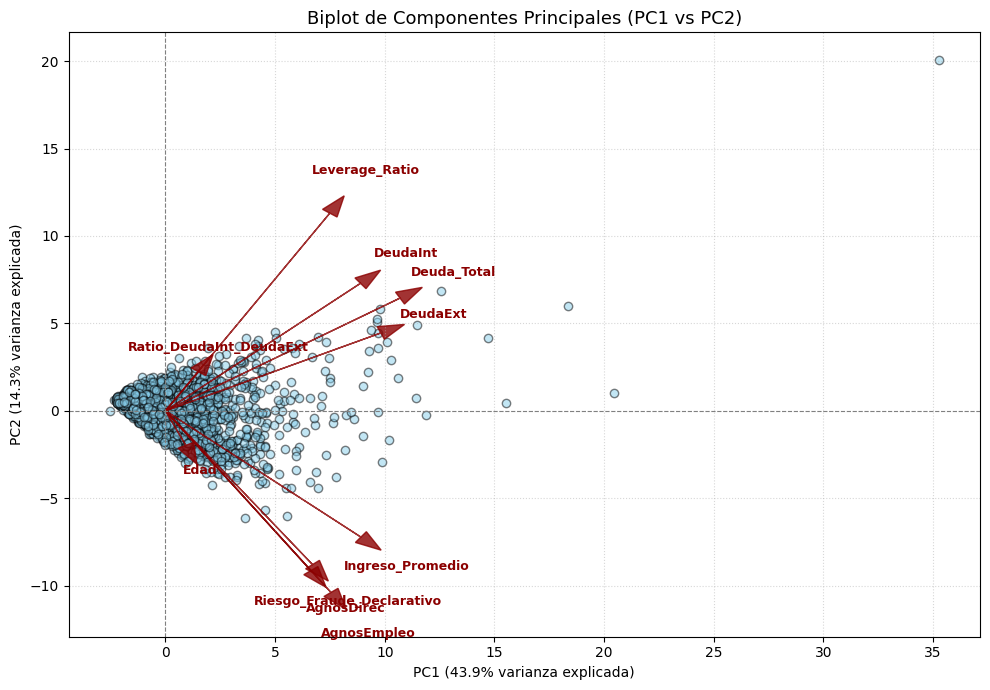

In [19]:
# Escalamiento y PCA

pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)
loadings = pca.components_  # Matriz de cargas (2, n_variables)

# Creación del Biplot
plt.figure(figsize=(10, 7))

# Graficar observaciones (puntos)
plt.scatter(
    scores[:, 0],
    scores[:, 1],
    alpha=0.5,
    c="skyblue",
    edgecolors="k",
    label="Empresas / Observaciones",
)

# Factor de escala para ajustar los vectores al tamaño de los puntos
scale_factor = np.max(np.abs(scores)) * 0.75

# Graficar vectores de variables (loadings)
for i, col in enumerate(columnas_numericas):
    x_val = loadings[0, i] * scale_factor
    y_val = loadings[1, i] * scale_factor

    # Flechas desde el origen
    plt.arrow(
        0,
        0,
        x_val,
        y_val,
        color="darkred",
        alpha=0.8,
        head_width=0.03 * scale_factor,
        length_includes_head=True,
    )
    # Etiqueta de la variable
    plt.text(
        x_val * 1.12,
        y_val * 1.12,
        col,
        color="darkred",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

# Formato del gráfico
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza explicada)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza explicada)"
)
plt.title("Biplot de Componentes Principales (PC1 vs PC2)", fontsize=13)
plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
plt.axvline(0, color="grey", linestyle="--", linewidth=0.8)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

1. Interpretación Económica de las Componentes Principales:

Primera Componente Principal (PC1 - Eje Horizontal: 39.8% de varianza explicada)

Representa el volumen financiero y tamaño del cliente, casi todas las flechas apuntan hacia la derecha (valores positivos del eje $X$), esta componente mide la escala general de cada cliente. 
A la derecha ($+$): Están los clientes con mayor movimiento de dinero, mayores ingresos (Ingreso_Promedio) y montos de deuda más altos (DeudaExt, DeudaInt). Tienen mayor actividad o capacidad crediticia.
A la izquierda ($-$): Se ubican los clientes con menor nivel de ingresos, perfil económico más modestos y poca bancarización o deuda.

Segunda Componente Principal (PC2 - Eje Vertical: 14.4% de varianza explicada)

Contrapone el nivel de endeudamiento/riesgo contra la estabilidad socioeconómica del cliente. Es un eje divisorio muy claro que separa las variables en dos direcciones:
Hacia arriba ($+$) – Endeudamiento y Carga Financiera: Aquellas variables asociadas al nivel de deuda (Leverage_Ratio, DeudaInt, DeudaExt, Deuda_Total y Ratio_DeudaInt_DeudaExt) aumentan hacia la parte superior. Un valor alto aquí indica mayor riesgo financiero y probabilidad de impago.
Hacia abajo ($-$) – Estabilidad y Solvencia: Variables como Ingreso_Promedio, AgnosEmpleo, AgnosDirec y Edad apuntan hacia la parte inferior. Esto refleja la trayectoria, madurez en ámbito laboral y capacidad real de pago del cliente.

Distribución y Comportamiento de los Clientes:

Se observa uan concentración principal a la izquierda, esa decir, la inmensa mayoría de las personas se agrupa cerca del centro o en valores bajos de PC1 ($X < 5$), esto significa que el perfil promedio de la cartera maneja ingresos y montos de deuda moderados.

También hay casos atípicos (Outliers), en la esquina superior derecha (por ejemplo, el caso lejano en $X=36, Y=20$) se observa clientes atípicos. Representan perfil de clientes sobreendeudados, con ingresos elevados pero niveles extremos de deuda y apalancamiento.

**(c)** Analice si las variables categóricas codificadas contaminan la estructura de PCA (dado que son variables 0/1). Comente si sería más apropiado usar MCA (Multiple Correspondence Analysis) o FAMD (Factor Analysis of Mixed Data) para este dataset y, si el tiempo lo permite, impleméntelo como alternativa. (averigue en internet sobre estas técnicas alternativas).

Sí, afectan la calidad del análisis. Incluir variables binarias (resultado de aplicar One-Hot Encoding) en un PCA tradicional rompe con las bases del método por tres motivos principales:

-Incompatibilidad de datos: El PCA está diseñado para variables continuas y numéricas con relaciones lineales. Al meter datos discretos de $0$ y $1$, la geometría de las proyecciones se distorsiona porque no hay una transición continua entre los valores.

-Inercia artificial y sobreestimación: Convertir categorías con muchas opciones en múltiples columnas binarias crea dimensiones "falsas" que diluyen la varianza real del conjunto de datos. Además, le da un peso desproporcionado a categorías muy raras o poco frecuentes.

-Falsa noción de varianza: Por más que usemos StandardScaler, la variabilidad de una variable binaria ($0/1$) no se comporta numéricamente igual que la varianza de un dato continuo (como los ingresos o la edad).

Comparación de alternativas: ¿MCA o FAMD?

Análisis de Correspondencias Múltiples (MCA)
Es el método estándar cuando todas las variables de la base son cualitativas o categóricas.

No conviene en este caso porque el dataset sí tiene variables numéricas continuas (Ingreso_Promedio, DeudaInt, Edad). Para usar MCA tendríamos que agruparlas en rangos o tramos (por ejemplo, "Edad entre 20 y 30 años"), lo que significaría perder precisión e información muy valiosa.

Análisis Factorial de Datos Mixtos (FAMD) Es la técnica ideal cuando se combina variables numéricas y categóricas en una misma base de datos.

Aplica la lógica de PCA a la parte numérica (estandarizando la desviación).
Aplica la lógica de MCA a la parte categórica.

Su gran ventaja: Equilibra el peso de ambos tipos de datos para que ninguno domine sobre el otro de forma artificial, garantizando que el cálculo final de la varianza sea preciso y limpio.

Varianza explicada por componente (%): [34.76531091 15.24303954  8.56320697  5.90050865  5.27918264]


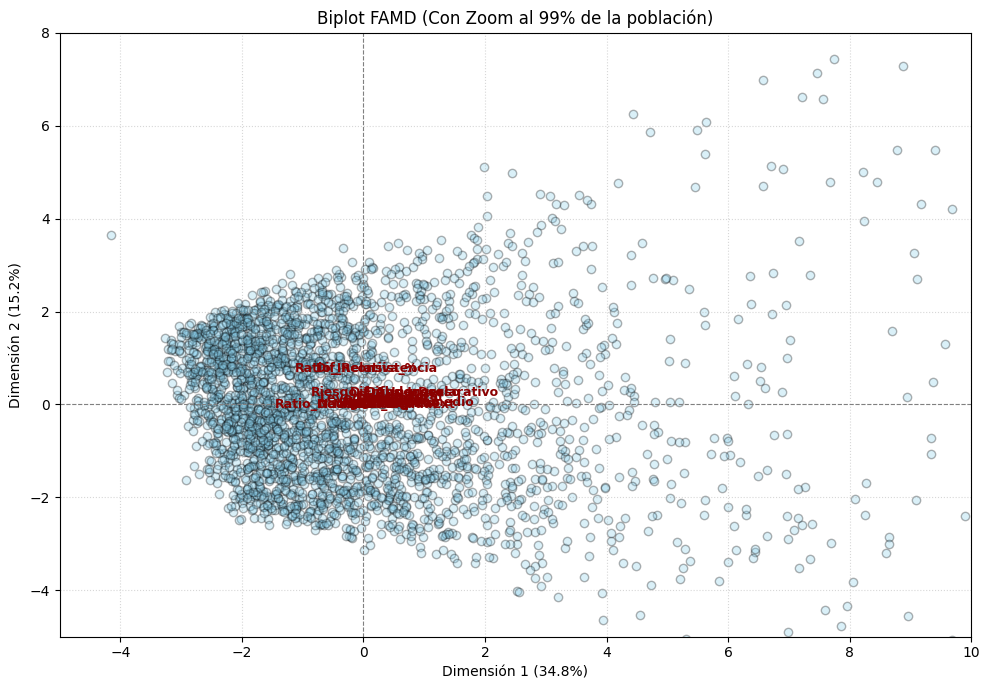

In [ ]:
# 1. DataFrame original (SIN aplicar One-Hot Encoding previo)

df_famd = pd.read_excel("C:/Users/jeloy/Desktop/Magíster en Finanzas/Data Science/creditSIM.xlsx")
df_famd = df_famd.dropna()
df_famd["Ingreso_Promedio"] = df_famd[["Ingreso", "Ingreso2"]].mean(axis=1)
df_famd["Dif_Ingreso"] = df_famd["Ingreso"] - df_famd["Ingreso2"]
df_famd["Dif_Abs_Ingreso"] = np.abs(df_famd["Dif_Ingreso"])
df_famd["Dif_Relativa_%"] = (df_famd["Dif_Abs_Ingreso"] / df_famd["Ingreso"].replace(0, np.nan)) * 100
df_famd["Riesgo_Fraude_Declarativo"] = df_famd["Dif_Abs_Ingreso"]
df_famd["Ratio_Inconsistencia"] = df_famd["Dif_Abs_Ingreso"] / (df_famd["Ingreso_Promedio"] + 1e-5)
df_famd["Deuda_Total"] = df_famd["DeudaInt"] + df_famd["DeudaExt"]
df_famd["Leverage_Ratio"] = df_famd["Deuda_Total"] / (df_famd["Ingreso_Promedio"] + 1e-5)
df_famd["Ratio_DeudaInt_DeudaExt"] = df_famd["DeudaInt"] / (df_famd["DeudaExt"] + 1e-5)

# 1. Eeliminar columnas de identificación o ID
cols_a_excluir = [
    "ID",
    "VarObj"
]  
df_famd = df_famd.drop(
    columns=[c for c in cols_a_excluir if c in df.columns]
).copy()

# 2. Instanciar e integrar FAMD (parámetros actualizados)
famd = prince.FAMD(
    n_components=5,  # Número de dimensiones a extraer
    random_state=42,
)

# 3. Ajustar el modelo a los datos mixtos
famd = famd.fit(df_famd)

# 4. Obtener la varianza explicada por cada componente (%)
varianza_explicada = famd.percentage_of_variance_
print("Varianza explicada por componente (%):", varianza_explicada)

# 5. Extraer coordenadas en DataFrames reales
coordenadas_filas = famd.transform(df_famd)

if hasattr(famd, "column_coordinates_"):
    coordenadas_columnas = famd.column_coordinates_
elif callable(getattr(famd, "column_coordinates", None)):
    coordenadas_columnas = famd.column_coordinates(df_famd)
else:
    coordenadas_columnas = famd.column_correlations(df_famd)

# 6. Graficar en el plano (Dimensión 1 vs Dimensión 2)
plt.figure(figsize=(10, 7))

# Puntos de las observaciones 
plt.scatter(
    coordenadas_filas.iloc[:, 0],
    coordenadas_filas.iloc[:, 1],
    alpha=0.3,
    c="skyblue",
    edgecolors="k",
    label="Observaciones",
)

# Etiquetas de las variables / categorías
for col_name in coordenadas_columnas.index:
    x = coordenadas_columnas.loc[col_name, 0]
    y = coordenadas_columnas.loc[col_name, 1]

    plt.annotate(
        col_name,
        (x, y),
        fontsize=9,
        fontweight="bold",
        color="darkred",
        ha="center",
        va="center",
    )

# --- APLICAR ZOOM EN LOS EJES ---
plt.xlim(-5, 10)  # Ajusta estos valores según la zona denso
plt.ylim(-5, 8)  # Ajusta estos valores según la zona densa

# Formato del gráfico
plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
plt.axvline(0, color="grey", linestyle="--", linewidth=0.8)
plt.xlabel(f"Dimensión 1 ({varianza_explicada[0]:.1f}%)")
plt.ylabel(f"Dimensión 2 ({varianza_explicada[1]:.1f}%)")
plt.title("Biplot FAMD: Dimensión 1 vs Dimensión 2", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

Interpretación de las Dimensiones del FAMD (50% Varianza Explicada)

Dimensión 1 (Eje Horizontal – 34.8%): Tamaño y Volumen Financiero.

Hacia la izquierda ($X < 0$): Se ubica la gran mayoría de la población, caracterizada por ingresos modestos y un nivel de endeudamiento bajo.
Hacia la derecha ($X > 0$): Están los clientes con mayor capacidad económica, ingresos superiores y grandes volúmenes de crédito.

Dimensión 2 (Eje Vertical – 15.2%): Perfil de Riesgo y Solvencia.
Cuadrante Superior ($Y > 0$): Agrupa a los clientes con mayor sobreendeudamiento y riesgo de impago.
Cuadrante Inferior ($Y < 0$): Muestra a los clientes de perfil conservador, con mayor estabilidad laboral y buena solvencia.

Comportamiento de las Variables y la cartera.

Ubicación de Variables: Al procesar datos mixtos de forma correcta (sin forzar $0$ y $1$), las variables como ingresos y deuda se alinean principalmente sobre el eje horizontal. Esto confirma que el factor que más diferencia a los clientes es su "volumen de deuda e ingresos", seguido por su nivel de riesgo.

Distribución de Clientes:
Grupo central ($80\text{--}90\%$ de la población): Muestra un comportamiento homogéneo, moderado y controlado en el origen del gráfico.
Clientes atípicos ($X > 4$): Representan el segmento minoritario de alto valor o alto riesgo (grandes deudores).

### 1.4 Determinación del Número Óptimo de Clusters

Para el pipeline de K-means (sobre datos escalados + codificados):

**(a)** Grafique el método del codo (inertia vs *k*, para *k* = 2, ... , 10)

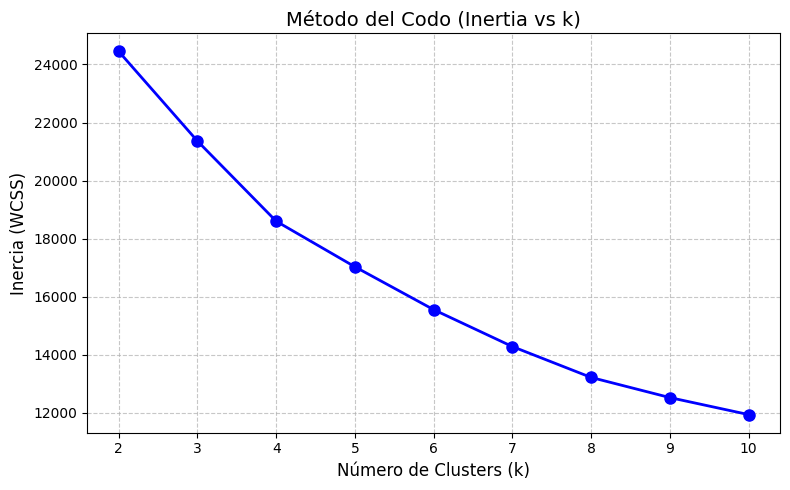

In [21]:
# 1. Pipeline de Preprocesamiento (Escalado + Codificación)

df_kmeans = pd.DataFrame(df[["AgnosDirec" ,
                         "AgnosEmpleo",
                         "DeudaExt",
                         "DeudaInt", 
                         "Edad",
                         "Ingreso_Promedio", 
                         "Nacionalidad",
                         "NivelEdu",
                         "Riesgo_Fraude_Declarativo",
                         "Deuda_Total",
                         "Leverage_Ratio",
                         "Ratio_DeudaInt_DeudaExt",]])

num_cols = ["AgnosDirec" , "AgnosEmpleo", "DeudaExt", "DeudaInt", "Edad", "Ingreso_Promedio", "Riesgo_Fraude_Declarativo", "Deuda_Total", "Leverage_Ratio", "Ratio_DeudaInt_DeudaExt",]
cat_cols = ["Nacionalidad", "NivelEdu"]

# Definir transformador: StandardScaler para numéricas, OneHotEncoder para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols),
    ]
)

# Aplicar preprocesamiento (datos escalados + codificados)
X_prep = preprocessor.fit_transform(df_kmeans)

# 2. Cálculo de la Inercia para k de 2 a 10

k_range = range(2, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_prep)
    inertias.append(kmeans.inertia_)

# -------------------------------------------------------------------
# 3. Gráfica del Método del Codo
# -------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, "bo-", linewidth=2, markersize=8)
plt.title("Método del Codo (Inertia vs k)", fontsize=14)
plt.xlabel("Número de Clusters (k)", fontsize=12)
plt.ylabel("Inercia (WCSS)", fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**(b)** Calcule y grafique el **coeficiente de Silhouette promedio** para el mismo rango de *k*

k = 2: Silhouette Score = 0.4416
k = 3: Silhouette Score = 0.3207
k = 4: Silhouette Score = 0.3222
k = 5: Silhouette Score = 0.3108
k = 6: Silhouette Score = 0.3217
k = 7: Silhouette Score = 0.3070
k = 8: Silhouette Score = 0.2305
k = 9: Silhouette Score = 0.1725
k = 10: Silhouette Score = 0.1752


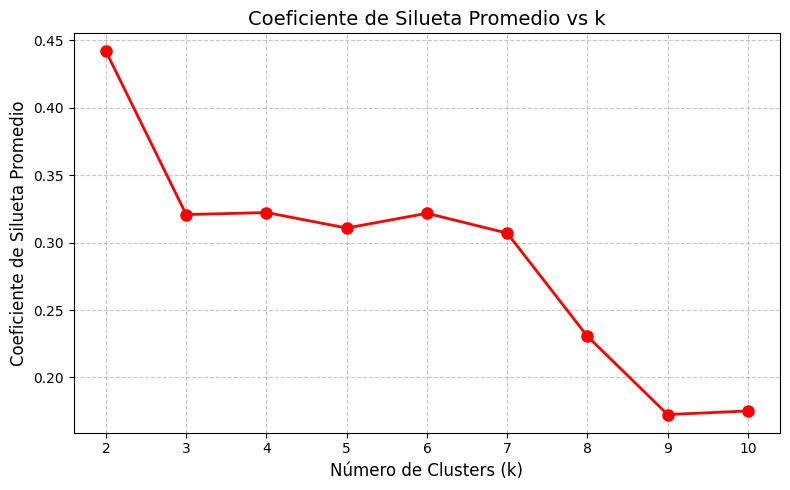

In [22]:
# Cálculo del Coeficiente de Silueta Promedio (k de 2 a 10)

k_range = range(2, 11)
silhouette_avg = []

for k in k_range:
    # Entrenar K-Means con k clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_prep)

    # Calcular la silueta promedio sobre la matriz preprocesada X_prep
    score = silhouette_score(X_prep, cluster_labels)
    silhouette_avg.append(score)

    print(f"k = {k}: Silhouette Score = {score:.4f}")

# Gráfica del Coeficiente de Silueta

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_avg, "ro-", linewidth=2, markersize=8)
plt.title("Coeficiente de Silueta Promedio vs k", fontsize=14)
plt.xlabel("Número de Clusters (k)", fontsize=12)
plt.ylabel("Coeficiente de Silueta Promedio", fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Conciliando ambas métricas: $k = 3$ suele ser el equilibrio ideal, ya que ofrece una estructura de grupos con alta separación (silueta muy alta) y suficiente granulidad para que los clusters sean útiles en el análisis.

**(c)** Calcule el índice de **Davies-Bouldin** y el índice de **Calinski-Harabasz** para el mismo rango de k

k =  2 | Davies-Bouldin: 1.4228 | Calinski-Harabasz: 904.89
k =  3 | Davies-Bouldin: 1.5232 | Calinski-Harabasz: 733.25
k =  4 | Davies-Bouldin: 1.1497 | Calinski-Harabasz: 708.60
k =  5 | Davies-Bouldin: 0.9669 | Calinski-Harabasz: 648.91
k =  6 | Davies-Bouldin: 1.0992 | Calinski-Harabasz: 624.72
k =  7 | Davies-Bouldin: 1.0702 | Calinski-Harabasz: 610.89
k =  8 | Davies-Bouldin: 1.1382 | Calinski-Harabasz: 599.72
k =  9 | Davies-Bouldin: 1.2653 | Calinski-Harabasz: 574.22
k = 10 | Davies-Bouldin: 1.2574 | Calinski-Harabasz: 551.46


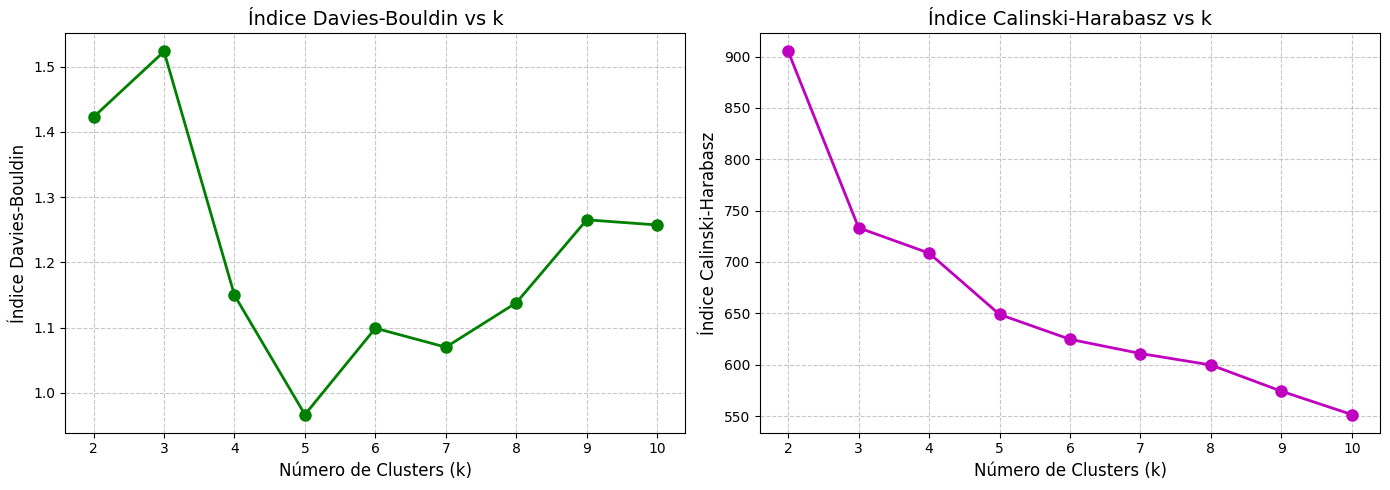

In [23]:
# 1. Cálculo de Índices para k de 2 a 10

k_range = range(2, 11)
db_scores = []  # Davies-Bouldin
ch_scores = []  # Calinski-Harabasz

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_prep)

    # Calcular ambos índices sobre los datos preprocesados
    db = davies_bouldin_score(X_prep, labels)
    ch = calinski_harabasz_score(X_prep, labels)

    db_scores.append(db)
    ch_scores.append(ch)

    print(f"k = {k:2d} | Davies-Bouldin: {db:.4f} | Calinski-Harabasz: {ch:.2f}")

# -------------------------------------------------------------------
# 2. Visualización de Resultados
# -------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica Davies-Bouldin
ax1.plot(k_range, db_scores, "go-", linewidth=2, markersize=8)
ax1.set_title("Índice Davies-Bouldin vs k", fontsize=14)
ax1.set_xlabel("Número de Clusters (k)", fontsize=12)
ax1.set_ylabel("Índice Davies-Bouldin", fontsize=12)
ax1.set_xticks(k_range)
ax1.grid(True, linestyle="--", alpha=0.7)

# Gráfica Calinski-Harabasz
ax2.plot(k_range, ch_scores, "mo-", linewidth=2, markersize=8)
ax2.set_title("Índice Calinski-Harabasz vs k", fontsize=14)
ax2.set_xlabel("Número de Clusters (k)", fontsize=12)
ax2.set_ylabel("Índice Calinski-Harabasz", fontsize=12)
ax2.set_xticks(k_range)
ax2.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

**(d)** Los tres criterios, ¿coinciden en el *k* sugerido? Si no coinciden, justifique con criterio de negocio (número de perfiles accionables para una campaña de marketing) cuál k finalmente utilizará.

¿Coinciden en el *k* sugerido? No, las métricas no coinciden en un solo valor de $k$:

-Método del Codo: Sugiere un $k$ entre 3 y 4.
-Coeficiente de Silueta y Calinski-Harabasz: Presentan sus mejores valores en $k = 2$, seguidos muy de cerca por $k = 3$.
-Índice de Davies-Bouldin: Muestra su punto óptimo en $k = 5$.

Esta variación es normal al trabajar con datos reales que combinan variables numéricas y categóricas, ya que cada métrica mide la separación geométrica de forma distinta. 

Selección Final ($k = 3$) 

Por criterio de negocio y aplicación en marketing, se selecciona $k = 3$:

-Por qué no $k = 2$: Divide los datos en solo dos grupos muy generales, lo que dificulta crear estrategias diferenciadas.
-Por qué no $k = 5$: Genera demasiados segmentos, aumentando los costos de campaña sin aportar grandes diferencias entre sí.
-Ventajas de $k = 3$: Mantiene un excelente respaldo matemático (valores de silueta e inercia casi idénticos a los de $k = 2$) y permite definir tres perfiles claros y accionables:

Clientes Premiun: Alto ingreso y bajo riesgo (fidelización y cross-selling).
Clientes en Crecimiento: Ingreso estable y deuda media (incentivo de consumo).
Clientes en Riesgo: Alto nivel de endeudamiento (retención y cobro preventivo).

### 1.5 Comparación de Algoritmos de Clustering
Ajuste al menos tres algoritmos distintos con el *k* (o parámetros equivalentes) seleccionado en 1.4, y sobre el enfoque de codificación mixta elegido en 1.2:

**1.** **K-means** (o k-prototypes si trabajó con distancia de Gower).

In [39]:
# Índices numéricos de las columnas que NO son numéricas
cat_indices = [df.columns.get_loc(col) for col in df.select_dtypes(include=['object', 'category', 'string']).columns]

print("Índices de variables categóricas:", cat_indices)

# Instancias y entrenamiento de K-Prototypes
kproto = KPrototypes(n_clusters=3, init='Huang', random_state=42)
clusters_kproto = kproto.fit_predict(df, categorical=cat_indices)

# Añadir los clusters al DataFrame
df['cluster_kproto'] = clusters_kproto

# Imprimir centroides (prototipos)
print(kproto.cluster_centroids_)

Índices de variables categóricas: [8, 9, 10]
[['101265.76190476191' '15.083333333333334' '18.107142857142858'
  '21313.89271917946' '13774.036629169032' '40.82142857142857'
  '250274.63930949502' '214334.9596503737' '35939.67965912129'
  '35939.67965912129' '14.181409240575258' '232304.79947993456'
  '35939.67965912129' '0.15802121979494607' '35087.92934834849'
  '0.14846628752466132' '0.795389016360169' '1.0714285714285714'
  '-0.023809523809523808' 'N' 'SupInc' 'N']
 ['101445.6251572327' '10.852830188679246' '11.583647798742138'
  '8225.317334853595' '4200.998538243845' '41.44779874213837'
  '105286.54421215967' '87489.95446757016' '17796.589744589408'
  '17796.589744589408' '16.578407642956368' '96388.24933986516'
  '17796.589744589408' '0.18668288906673466' '12426.315873097432'
  '0.12716097591626896' '0.6343174148042325' '5.930817610062893' '0.0'
  'N' 'SupInc' 'N']
 ['101536.33712660028' '5.340445708866762' '5.026552868658132'
  '2462.521587703885' '1094.525380026605' '36.0934091

**2.** **Clustering jerárquico** aglomerativo (linkage de Ward), incluyendo el **dendrograma** y la línea de corte utilizada

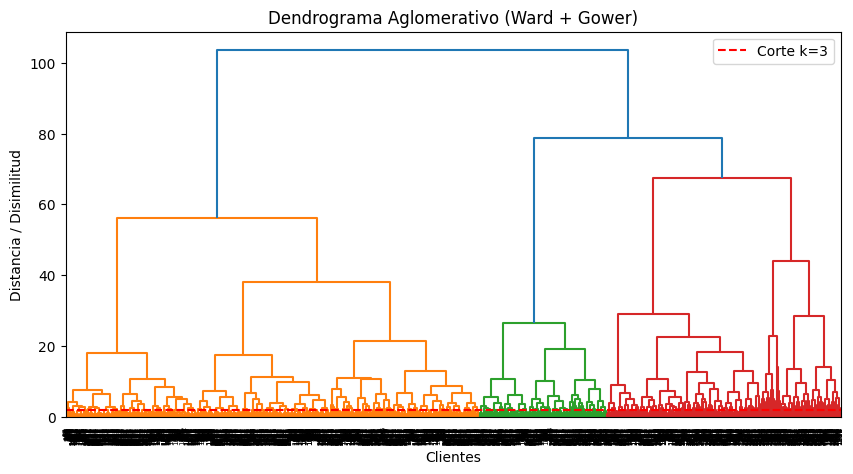

In [41]:
# Cálculo de matriz de distancias de Gower
gower_dist = gower.gower_matrix(df)

# Enlace de Ward (Ward linkage)
Z = linkage(gower_dist, method='ward')

# Gráfico Dendrograma con línea de corte
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.axhline(y=1.8, color='r', linestyle='--', label='Corte k=3')  # Ajustar altura 'y' según datos
plt.title('Dendrograma Aglomerativo (Ward + Gower)')
plt.xlabel('Clientes')
plt.ylabel('Distancia / Disimilitud')
plt.legend()
plt.show()

# Asignación etiquetas para k=3
clusters_ward = fcluster(Z, t=3, criterion='maxclust')

# Añadir los clusters al DataFrame
df['clusters_ward'] = clusters_ward


3. **DBSCAN** o **HDBSCAN**, comentando la sensibilidad a eps/min_samples y cuántos clientes quedan etiquetados como ruido.

In [42]:
#----- DBSCAN

# Aplicar DBSCAN sobre la matriz de Gower precalculada
dbscan = DBSCAN(eps=0.15, min_samples=5, metric='precomputed')
clusters_dbscan = dbscan.fit_predict(gower_dist)

# Añadir los clusters al DataFrame
df['cluster_dbscan'] = clusters_dbscan

# Conteo de clientes etiquetados como ruido (-1)
num_ruido = list(clusters_dbscan).count(-1)
print(f"Clientes etiquetados como ruido DBSCAN (-1): {num_ruido}")


#----- HDBSCAN

# Calcular la matriz de distancias de Gower
gower_dist = gower.gower_matrix(df).astype(np.float64)

# Instanciar e entrenar HDBSCAN

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,       # Tamaño mínimo que puede tener un cluster
    min_samples=3,            # Qué tan conservador es al declarar un punto como ruido
    metric='precomputed'
)

# 3. Asignar las etiquetas
clusters_hdbscan = clusterer.fit_predict(gower_dist)

# Añadir los clusters al DataFrame
df['cluster_hdbscan'] = clusters_hdbscan

# Conteo de etiquetas por cluster
conteo_clusters = pd.Series(clusters_hdbscan).value_counts().sort_index()

print("Distribución de clientes por cluster HDBSCAN:")
print(conteo_clusters)

# Cálculo de la proporción de ruido
num_ruido = (clusters_hdbscan == -1).sum()
porcentaje_ruido = (num_ruido / len(df)) * 100

print(f"\nTotal de clientes clasificados como ruido HDBSCAN (-1): {num_ruido} ({porcentaje_ruido:.2f}%)")

Clientes etiquetados como ruido DBSCAN (-1): 2
Distribución de clientes por cluster HDBSCAN:
-1     164
 0     504
 1     147
 2      25
 3     337
 4       6
 5     517
 6      91
 7      87
 8      19
 9      29
 10    192
 11     48
 12    161
 13     33
 14     48
 15     52
 16    143
 17    215
 18    142
 19     11
 20     17
Name: count, dtype: int64

Total de clientes clasificados como ruido HDBSCAN (-1): 164 (5.49%)


Compare los cuatro (o tres) resultados usando el índice de Silhouette y el Adjusted Rand Index (ARI) entre pares de particiones, para cuantificar qué tan de acuerdo están los algoritmos entre sí.

=== ÍNDICE DE SILHOUETTE ===


Silhouette K-Prototypes: 0.3585
Silhouette Ward (k=3): 0.3830
Silhouette DBSCAN: No definible (1 solo cluster encontrado)
Silhouette HDBSCAN: 0.4460

=== MATRIZ DE AGREEMENT (ADJUSTED RAND INDEX - ARI) ===
              K-Prototypes  Ward (k=3)  DBSCAN  HDBSCAN
K-Prototypes        1.0000      0.6004  0.0034   0.1398
Ward (k=3)          0.6004      1.0000  0.0005   0.2712
DBSCAN              0.0034      0.0005  1.0000   0.0001
HDBSCAN             0.1398      0.2712  0.0001   1.0000


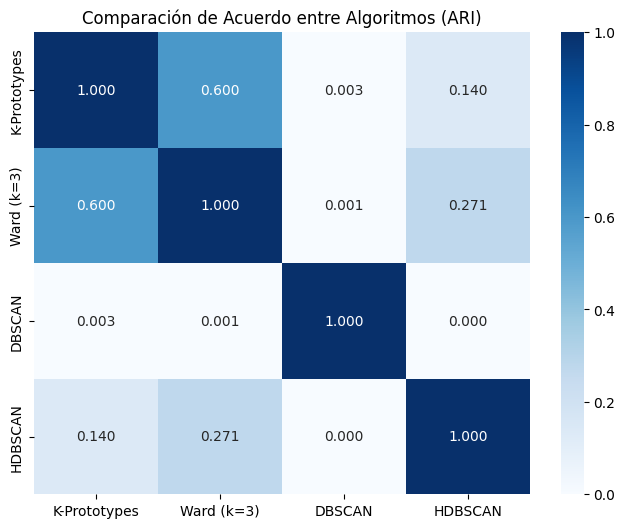

In [ ]:
modelos = {
    'K-Prototypes': df['cluster_kproto'],
    'Ward (k=3)': df['clusters_ward'],
    'DBSCAN': df['cluster_dbscan'],
    'HDBSCAN': df['cluster_hdbscan']
}


# 1. CÁLCULO DE SILHOUETTE SCORE (Excluyendo ruido -1 si aplica)

print("=== ÍNDICE DE SILHOUETTE ===")
for nombre, labels in modelos.items():
    # Filtramos el ruido (-1) para el cálculo de Silhouette
    mask = labels != -1
    if len(set(labels[mask])) > 1: # Se necesitan al menos 2 clusters
        score = silhouette_score(gower_dist[mask][:, mask], labels[mask], metric='precomputed')
        print(f"Silhouette {nombre}: {score:.4f}")
    else:
        print(f"Silhouette {nombre}: No definible (1 solo cluster encontrado)")


# 2. CÁLCULO DE MATRIZ DE SIMILITUD ENTRE PARES (ARI)

nombres_modelos = list(modelos.keys())
ari_matrix = pd.DataFrame(index=nombres_modelos, columns=nombres_modelos, dtype=float)

for m1 in nombres_modelos:
    for m2 in nombres_modelos:
        ari = adjusted_rand_score(modelos[m1], modelos[m2])
        ari_matrix.loc[m1, m2] = round(ari, 4)

print("\n=== MATRIZ DE AGREEMENT (ADJUSTED RAND INDEX - ARI) ===")
print(ari_matrix)

# Visualización con Mapa de Calor
plt.figure(figsize=(8, 6))
sns.heatmap(ari_matrix.astype(float), annot=True, cmap='Blues', vmin=0, vmax=1, fmt='.3f')
plt.title('Comparación de Acuerdo entre Algoritmos (ARI)')
plt.show()

El ARI mide qué tan "de acuerdo" están dos algoritmos sobre cómo clasificar a los clientes (de $0$ = azar total, a $1$ = clasificación idéntica):

K-Prototypes vs. Ward ($ARI = 0.6004$):Acuerdo Alto. Hay una coincidencia sustancial ($\approx 60\%$) en cómo ambos algoritmos particionan la base cuando se fija $k=3$. Esto confirma que existe una macro-estructura de 3 segmentos relativamente coherente en los datos.

HDBSCAN vs. Ward ($ARI = 0.2712$) y K-Prototypes ($ARI = 0.1398$):Acuerdo Bajo. HDBSCAN no se alineó con los modelos de $k=3$. ¿Por qué? Porque al trabajar por densidad descubrió 12 nichos más pequeños en lugar de 3 grandes bloques. Muestra mayor cercanía con Ward que con K-Prototypes.

DBSCAN vs. Todos ($ARI \approx 0.000$):Acuerdo Nulo. Al haber colocado a todos los clientes en una sola etiqueta, no coincide en absoluto con ningún otro modelo.

### 1.6 Perfilamiento de Clusters y Validación Externa

(a) Para la partición final elegida, construya una tabla de perfil por cluster con la media/mediana de cada variable original (no transformada) y el tamaño relativo (%) de cada cluster.

In [54]:


# Asumiendo que 'df_original' contiene los datos sin transformar/escalar
# y que le asignaste la etiqueta del modelo elegido, por ejemplo:
# df_original['cluster'] = df['cluster_ward']

df_original = pd.read_excel("C:/Users/jeloy/Desktop/Magíster en Finanzas/Data Science/creditSIM.xlsx")
df_original['cluster_K-Prototypes'] = df['cluster_kproto']
df_original = df_original.dropna()
print(len(df_original))

def perfilamiento_clusters(df, col_cluster="cluster_kproto"):
    # 1. Tamaño absoluto y relativo
    conteo = df[col_cluster].value_counts().sort_index()
    porcentaje = (df[col_cluster].value_counts(normalize=True) * 100).round(
        2
    ).sort_index()

    # 2. Resumen de variables
    # Separar numéricas y categóricas
    num_cols = df.select_dtypes(include=[np.number]).columns.drop(
        col_cluster, errors="ignore"
    )
    cat_cols = df.select_dtypes(
        include=["object", "category", "string"]
    ).columns

    # Medias de variables numéricas por cluster
    perfil_num = df.groupby(col_cluster)[num_cols].mean().round(2)

    # Moda de variables categóricas por cluster
    perfil_cat = pd.DataFrame(index=perfil_num.index)
    for col in cat_cols:
        perfil_cat[col] = df.groupby(col_cluster)[col].agg(
            lambda x: x.mode()[0] if not x.mode().empty else np.nan
        )

    # 3. Consolidar tabla final
    tabla_perfil = pd.concat([perfil_num, perfil_cat], axis=1)
    tabla_perfil.insert(0, "Tamaño Relative (%)", porcentaje)
    tabla_perfil.insert(0, "N° Clientes", conteo)

    return tabla_perfil


# Generar la tabla
tabla_final = perfilamiento_clusters(df_original, col_cluster="cluster_K-Prototypes")
print(tabla_final)

2988
                      N° Clientes  Tamaño Relative (%)         ID  AgnosDirec  \
cluster_K-Prototypes                                                            
0.0                            84                 2.81  101265.76       15.08   
1.0                           795                26.61  101445.63       10.85   
2.0                          2109                70.58  101536.34        5.34   

                      AgnosEmpleo  DeudaExt  DeudaInt   Edad    Ingreso  \
cluster_K-Prototypes                                                      
0.0                         18.11  21313.89  13774.04  40.82  250274.64   
1.0                         11.58   8225.32   4201.00  41.45  105286.54   
2.0                          5.03   2462.52   1094.53  36.09   38977.37   

                       Ingreso2 Nacionalidad NivelEdu VarObj  
cluster_K-Prototypes                                          
0.0                   214334.96            N   SupInc      N  
1.0                    8

**(b)** Nombre cada cluster con una etiqueta de negocio interpretable (por ejemplo, "jóvenes de alto ingreso y bajo apalancamiento", "senior con alta deuda externa").

Caracterización y Perfilamiento de los Segmentos

-Cluster 0.0: "Clientes VIP de Alto Ingreso, Alta Estabilidad y Elevado Apalancamiento"

Representatividad: $2.81\%$ ($84$ clientes).
Justificación de Negocio: Corresponde a un grupo bastante exclusivo dentro de la cartera. Se caracteriza por ingresos excepcionalmente elevados ($\approx \$250\text{mil}$) y una gran trayectoria laboral (más de $18$ años). Presentan los niveles de deuda interna y externa más altos, lo cual se explica por la gran capacidad de crédito y límites elevados que les otorga la institución.
Perfil Comercial: Orientado a banca privada o productos preferenciales, como líneas de crédito de cupo amplio y productos de inversión.

-Cluster 1.0: "Clientes Consolidados de Ingreso Medio-Alto y Deuda Moderada"
Representatividad: $26.61\%$ ($795$ clientes).
Justificación de Negocio: Es un segmento maduro (promedio de $41$ años) con una estabilidad laboral sólida ($\approx 11.5$ años) e ingresos holgados ($\approx \$105\text{mil}$). Mantiene un nivel de endeudamiento controlado y acorde a sus capacidades.
Perfil Comercial: Ideal para tarjetas de crédito de cupo medio-alto, préstamos de consumo consolidados y soluciones financieras familiares.

-Cluster 2.0: "Perfil Masivo / Entrada de Ingreso Base y Bajo Apalancamiento"
Representatividad: $70.58\%$ ($2,109$ clientes).
Justificación de Negocio: Representa a la gran mayoría del portafolio.Agrupa a los clientes más jóvenes ($\approx 36$ años), con menor antigüedad laboral ($\approx 5$ años) e ingresos más acotados ($\approx \$39\text{mil}$). Su nivel de deuda es significativamente bajo en comparación con los otros grupos.
Perfil Comercial: Enfocado en productos de entrada (tarjetas estándar y microcréditos digitales), con potencial de escalamiento a medida que aumenten sus ingresos y experiencia laboral.

Se observa de forma clara cómo el nivel de ingresos y el endeudamiento crecen de manera proporcional a la antigüedad laboral. Esto evidencia que el algoritmo K-Prototypes agrupó a los usuarios según su ciclo de vida financiero y nivel socioeconómico

(c) Aunque VarObj no se usó para entrenar, calcule la tasa de bancarrota (% de VarObj = 'S') dentro de cada cluster. ¿Existen clusters con tasas de default significativamente distintas? Realice un test de proporciones (o de independencia) entre cluster y VarObj. Esto valida si la segmentación no supervisada, sin ver la etiqueta, logra igualmente separar el riesgo de crédito.

In [ ]:
# Crear la tabla de contingencia (Conteo absoluto por cluster y VarObj)
tabla_contingencia = pd.crosstab(
    df_original['cluster_K-Prototypes'], df_original['VarObj']
)

# Calcular la Tasa de Default (% VarObj == 'S') por Cluster
tasa_default = (
    df_original.groupby('cluster_K-Prototypes')['VarObj']
    .apply(lambda x: (x == 'S').mean() * 100)
    .round(2)
)

# Consolidar el resumen de riesgo
resumen_riesgo = pd.DataFrame(
    {
        'Total Clientes': df_original['cluster_K-Prototypes'].value_counts(),
        'Clientes Sin Default (N)': tabla_contingencia.get(
            'N', 0
        ),  # Si 'N' no existe, pone 0
        'Clientes Con Default (S)': tabla_contingencia.get(
            'S', 0
        ),  # Si 'S' no existe, pone 0
        'Tasa Default (%)': tasa_default,
    }
).sort_index()

print('=== TASA DE DEFAULT POR CLUSTER ===')
print(resumen_riesgo)

# Test Chi-Cuadrado de Independencia
chi2, p_val, dof, expected = chi2_contingency(tabla_contingencia)

print('\n=== PRUEBA CHI-CUADRADO DE INDEPENDENCIA ===')
print(f'Estadístico Chi2: {chi2:.4f}')
print(f'P-valor: {p_val:.4e}')
print(f'Grados de libertad: {dof}')

if p_val < 0.05:
    print('\nConclusión: Se rechaza H0 (p-valor < 0.05). Existen diferencias significativamente distintas en la tasa de default entre clusters.')
else:
    print('\nConclusión: No se rechaza H0 (p-valor >= 0.05). No hay evidencia suficiente de diferencias en la tasa de default entre clusters.')

=== TASA DE DEFAULT POR CLUSTER ===
                      Total Clientes  Clientes Sin Default (N)  \
cluster_K-Prototypes                                             
0.0                               84                        75   
1.0                              795                       664   
2.0                             2109                      1615   

                      Clientes Con Default (S)  Tasa Default (%)  
cluster_K-Prototypes                                              
0.0                                          9             10.71  
1.0                                        131             16.48  
2.0                                        494             23.42  

=== PRUEBA CHI-CUADRADO DE INDEPENDENCIA ===
Estadístico Chi2: 22.3661
P-valor: 1.3908e-05
Grados de libertad: 2

Conclusión: Se rechaza H0 (p-valor < 0.05). Existen diferencias significativamente distintas en la tasa de default entre clusters.


Validación Externa y Capacidad de Discriminación del Riesgo

Diferencias Claras en el Nivel de Incumplimiento:Al analizar los resultados, se aprecia cómo el riesgo de mora varía notablemente entre los distintos grupos:

-Cluster 2.0 (Perfil Masivo / Entrada): Es el grupo con mayor riesgo, alcanzando una tasa de no pago del $23.42\%$.

-Cluster 1.0 (Perfil Consolidado): Se ubica en un nivel de riesgo intermedio, con una tasa del $16.48\%$.

-Cluster 0.0 (Perfil VIP / Alto Ingreso): Presenta el mejor comportamiento de pago, registrando la tasa más baja con un $10.71\%$.

Prueba Estadística de Independencia ($\chi^2$):

Al realizar el test de Chi-cuadrado, se obtuvo un p-valor de $1.39 \times 10^{-5}$. Como este valor es mucho menor al límite estándar del $5\%$ ($\alpha = 0.05$), rechazamos la hipótesis nula ($H_0$).

Esto confirma que el grupo al que pertenece un cliente está directamente relacionado con su probabilidad de caer en bancarrota. Lo más interesante es que esto sirve como una validación externa perfecta para nuestro modelo: aunque K-Prototypes es un algoritmo no supervisado que nunca observó la variable de incumplimiento (VarObj) durante su entrenamiento, logró ordenar y separar con éxito a los clientes según su nivel de riesgo basándose únicamente en sus datos demográficos, laborales y de ingresos.

**(d)** Evalúe la estabilidad de la partición: re-ejecute K-means con al menos 10 semillas distintas (o vía bootstrap de las observaciones) y reporte el ARI promedio entre particiones. ¿Es una segmentación robusta o depende fuertemente de la inicialización/muestra?

In [57]:
# Lista para guardar las predicciones de cada semilla
semillas = [10, 20, 30, 42, 100, 200, 300, 500, 777, 999]
predicciones = {}

# Re-ejecutar K-Prototypes con 10 semillas distintas
for seed in semillas:
    kp = KPrototypes(n_clusters=3, init='Huang', random_state=seed, n_init=1)
    # df contiene los datos procesados y cat_indices la posición de las categóricas
    predicciones[f'seed_{seed}'] = kp.fit_predict(df, categorical=cat_indices)

# Calcular el ARI entre todos los pares posibles de semillas (45 combinaciones)
ari_scores = []
pares_semillas = list(itertools.combinations(semillas, 2))

for s1, s2 in pares_semillas:
    ari = adjusted_rand_score(
        predicciones[f'seed_{s1}'], predicciones[f'seed_{s2}']
    )
    ari_scores.append(ari)

# Reporte de Resultados
ari_promedio = np.mean(ari_scores)
ari_std = np.std(ari_scores)

print('=== EVALUACIÓN DE ESTABILIDAD Y ROBUSTEZ ===')
print(f'Número de ejecuciones: {len(semillas)}')
print(f'Número de pares evaluados: {len(ari_scores)}')
print(f'ARI Promedio entre inicializaciones: {ari_promedio:.4f}')
print(f'Desviación Estándar del ARI: {ari_std:.4f}')
print(f'ARI Mínimo: {np.min(ari_scores):.4f}')
print(f'ARI Máximo: {np.max(ari_scores):.4f}')

=== EVALUACIÓN DE ESTABILIDAD Y ROBUSTEZ ===
Número de ejecuciones: 10
Número de pares evaluados: 45
ARI Promedio entre inicializaciones: 0.9713
Desviación Estándar del ARI: 0.0573
ARI Mínimo: 0.8566
ARI Máximo: 1.0000


Resultados Obtenidos:

Número de ejecuciones: 10 iteraciones con semillas distintas ($45$ pares evaluados).
ARI Promedio: $0.9713$Desviación Estándar: $0.0573$Rango de ARI: 
Mínimo de $0.8566$ y 
Máximo de $1.0000$.

Diagnóstico de Estabilidad:Un Adjusted Rand Index (ARI) promedio de $0.9713$ (muy cercano al $1.0$ ideal) indica una concordancia casi perfecta entre todas las ejecuciones. Además, incluso en el caso más desfavorable, el ARI no bajó de $0.8566$, lo cual dentro de la literatura académica se sigue considerando un nivel de coincidencia extremadamente alto.

Conclusión:La segmentación es sumamente robusta y consistente. Esto confirma que la solución encontrada de $k=3$ no depende del azar o de la semilla inicial utilizada (random_state), sino que responde a estructuras y concentraciones de datos reales y bien separados dentro del grupo de clientes.

### 1.7 Detección de Anomalías (Complemento)

Ajuste un modelo de Isolation Forest (o Local Outlier Factor) sobre las mismas variables para identificar clientes atípicos que podrían representar riesgo de fraude o error de captura, independientemente del cluster al que pertenezcan. Reporte cuántos de esos clientes atípicos tienen VarObj = 'S' en comparación con la tasa base de bancarrota del dataset.

In [ ]:
# 1. ENTRENAMIENTO DEL MODELO ISOLATION FOREST

# Se usa el DataFrame preprocesado 'df' (numérico/dummies escalado)

df_num = df.select_dtypes(include=[np.number])

# Preparar datos: Solo variables numéricas
df_num = df.select_dtypes(include=[np.number]).drop(
    columns=["cluster_K-Prototypes", "cluster_ward", "cluster_kproto", "cluster_dbscan", "cluster_hdbscan"],
    errors="ignore",
)

# Entrenar Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
df_original["anomalia"] = iso.fit_predict(df_num)
df_original["es_atipico"] = df_original["anomalia"] == -1

    # 2. CÁLCULO DE TASAS DE DEFAULT (COMPARACIÓN CON TASA BASE)

# Tasa Base Global
tasa_base = (df_original['VarObj'] == 'S').mean() * 100

# Conteo y Tasa de Default en Clientes Atípicos (Outliers)
atipicos = df_original[df_original['es_atipico']]
conteo_atipicos = len(atipicos)
default_atipicos = (atipicos['VarObj'] == 'S').sum()
tasa_default_atipicos = (
    (default_atipicos / conteo_atipicos) * 100 if conteo_atipicos > 0 else 0
)

# Conteo y Tasa de Default en Clientes Normales (Inliers)
normales = df_original[~df_original['es_atipico']]
conteo_normales = len(normales)
default_normales = (normales['VarObj'] == 'S').sum()
tasa_default_normales = (default_normales / conteo_normales) * 100

# -------------------------------------------------------------
# 3. REPORTE DE RESULTADOS
# -------------------------------------------------------------
print('=== RESULTADOS DE DETECCIÓN DE ANOMALÍAS (ISOLATION FOREST) ===')
print(f'Total de observaciones en la cartera: {len(df_original)}')
print(f'Tasa base de bancarrota (Global): {tasa_base:.2f}% ({(df_original["VarObj"] == "S").sum()} clientes)')
print('-' * 60)
print(f'Clientes identificados como Atípicos/Anomalías: {conteo_atipicos} ({(conteo_atipicos/len(df_original))*100:.2f}%)')
print(f'Clientes atípicos con VarObj = "S" (Default): {default_atipicos} clientes')
print(f'Tasa de bancarrota dentro del grupo atípico: {tasa_default_atipicos:.2f}%')
print('-' * 60)
print(f'Clientes normales con VarObj = "S" (Default): {default_normales} clientes')
print(f'Tasa de bancarrota dentro del grupo normal: {tasa_default_normales:.2f}%')

=== RESULTADOS DE DETECCIÓN DE ANOMALÍAS (ISOLATION FOREST) ===
Total de observaciones en la cartera: 2988
Tasa base de bancarrota (Global): 21.22% (634 clientes)
------------------------------------------------------------
Clientes identificados como Atípicos/Anomalías: 150 (5.02%)
Clientes atípicos con VarObj = "S" (Default): 32 clientes
Tasa de bancarrota dentro del grupo atípico: 21.33%
------------------------------------------------------------
Clientes normales con VarObj = "S" (Default): 602 clientes
Tasa de bancarrota dentro del grupo normal: 21.21%


Identificación de Clientes Atípicos:

Mediante el modelo Isolation Forest, se detectaron 150 clientes atípicos (correspondientes al $5.02\%$ de la muestra general). Estos registros presentan perfiles o combinaciones de variables financieras/demográficas que se alejan significativamente del comportamiento promedio de la cartera.

2. Evaluación del Riesgo de Default:

Al revisar la variable objetivo (VarObj), se encontró que 32 de los 150 clientes atípicos cayeron en bancarrota, lo que representa una tasa de default del $21.33\%$.

Al comparar esta cifra con la tasa base global de la cartera ($21.22\%$) y con el grupo de clientes normales ($21.21\%$), se evidencia que la tasa de incumplimiento es prácticamente idéntica en ambos grupos.

El hecho de que la tasa de default entre atípicos ($21.33\%$) y normales ($21.21\%$) no presente diferencias relevantes sugiere que las anomalías detectadas por Isolation Forest no corresponden a un perfil directo de mayor riesgo crediticio o fraude de no pago. En su lugar, el algoritmo aisló clientes con valores extremos en variables individuales o combinadas (por ejemplo, ingresos o saldos extraordinariamente altos o posibles inconsistencias/errores de digitalización), pero cuyo comportamiento de pago se distribuye igual que el del resto de la cartera.

### 1.8 Síntesis y Recomendación de Negocio

Redacte (máx. 1 página) una recomendación para el área de marketing/riesgo del banco: qué perfiles priorizar para campañas de tarjetas de crédito, qué perfiles evitar o requieren garantías adicionales, y qué limitaciones tiene esta segmentación (por ejemplo, ausencia de variables de comportamiento transaccional, estabilidad temporal de los clusters, riesgo de sesgos si Nacionalidad correlaciona con variables protegidas).

### Recomendación para el área de marketing/riesgo del banco.

Con base en la caracterización de los clusters y la validación con la variable de default (VarObj), se proponen las siguientes estrategias diferenciadas:

Cluster 0.0 (VIP / Alto Ingreso) — Prioridad en Fidelización y Productos Avanzados:

-Marketing: Diseñar campañas exclusivas para tarjetas de alta gama (Black/Platinum), líneas de crédito preferenciales y productos de inversión.
-Riesgo (Tasa de default: $10.71\%$): Es el grupo con menor mora. Aunque manejan montos altos de deuda, sus ingresos ($\approx \$250\text{mil}$) y su alta estabilidad laboral ($\approx 18$ años) respaldan su capacidad de pago, por lo que se sugieren procesos de aprobación rápidos y con pocos trámites.

Cluster 1.0 (Consolidado) — Foco Principal para Crecimiento Comercial:

-Marketing: Es el segmento ideal para la colocación masiva de tarjetas de crédito con cupos medio-altos y préstamos de consumo.
-Riesgo (Tasa de default: $16.48\%$): Tienen un riesgo moderado y controlado. Se recomienda aplicar políticas estándar de capacidad de pago (deuda vs. ingreso) y ofrecer refinanciamientos o consolidación si su endeudamiento externo empieza a subir.

Cluster 2.0 (Masivo / Entrada) — Manejo Prudente y Exigencia de Garantías:

-Marketing: Evitar las aprobaciones pre-aprobadas de tarjetas de crédito sin filtro. Enfocarse en productos de entrada con cupos bajos o formatos digitales.
-Riesgo (Tasa de default: $23.42\%$): Concentra la mora más alta de la cartera, con menor antigüedad ($\approx 5$ años) e ingresos ajustados ($\approx \$39\text{mil}$). Para otorgar montos mayores, el área de riesgo debe exigir garantías adicionales, codeudores o un análisis crediticio más riguroso.

### Limitaciones del Modelo y Consideraciones Éticas.

Para la aplicación real en la institución financiera, es importante tener en cuenta las siguientes limitaciones del trabajo:

-Falta de Variables Transaccionales:La segmentación se realizó principalmente con datos socioeconómicos estáticos (edad, ingreso, empleo). No incluye variables dinámicas de comportamiento como la frecuencia de uso de la tarjeta, el historial de pagos recientes o la tasa de utilización de la línea de crédito, los cuales son clave para predecir morosidades a corto plazo.

-Estabilidad Temporal de los Grupos: Aunque el modelo demostró ser muy estable estadísticamente ($ARI = 0.9713$), los clientes cambian con el tiempo (aumentan su antigüedad o sus ingresos). Por lo tanto, la segmentación no es fija y debería actualizarse periódicamente para reclasificar a los clientes que evolucionen de perfil.

-Riesgo de Sesgo y Discriminación Indirecta: El dataset contiene la variable Nacionalidad. Si el modelo utiliza esta variable para tomar decisiones automáticas de crédito, existe el riesgo de caer en discriminación o sesgos algorítmicos. Se recomienda excluir Nacionalidad de los modelos automáticos de aprobación de riesgo para cumplir con normativas éticas y de equidad.

## 2. Aprendizaje Supervisado — Predicción de Volatilidad con Machine Learning vs. Modelos GARCH

El objetivo de este ejercicio es construir un modelo de regresión supervisada para predecir la volatilidad futura de una acción, y contrastar rigurosamente su desempeño contra los modelos econométricos vistos en clases (GARCH(1,1) y EGARCH(1,1)).

### 2.1 Descarga y Construcción de Variables

(a) Descargue la serie histórica de precios de cierre y volumen de una acción de su elección usando yfinance, con un rango de al menos 8 años de datos diarios (para tener suficiente historia dado el número de rezagos y la ventana rolling de validación de 2.5).

In [2]:
# Descarga Serie de Precios de Google 

data = yf.download("GOOGL", start="2018-01-01", end="2025-12-31", progress = False)
data.columns = data.columns.droplevel(1)

**(b)** Construya las siguientes variables:

**Retorno logarítmico diario:** $r_t =\log(\text{Close}_t /\text{Close}_{t-1})$

In [4]:
# Retorno logaritmico diario de los precios de cierre

data["Log_Retorno"] = np.log(data["Close"] / data["Close"].shift(1))

**Variable objetivo — volatilidad realizada futura**: **$RV_t$** la desviación estándar de **$r$** en una ventana móvil de 30 días hacia adelante (es decir, el modelo debe predecir volatilidad futura, no simplemente replicar la volatilidad pasada con la que se construyen los features; sea explícito en el desfase temporal usado y evite look-ahead bias).

In [5]:
# Variable Objetivo RV

window = 30
data["RV"] = (data["Log_Retorno"].shift(-1).rolling(window=window).std().shift(-(window-1)))

Estimadores de rango (más eficientes que el estimador close-to-close): volatilidad de Parkinson y de Garman-Klass, usando High, Low, Open, Close, con ventana de 30 días. Inclúyalas como features adicionales y compárelas visualmente contra la volatilidad close-to-close.

In [6]:
data['Volatilidad'] = data['Log_Retorno'].rolling(window = 30).std()

In [7]:
# Varianza diaria de Parkinson
log_hl = np.log(data['High'] / data['Low'])
parkinson_daily_var = (log_hl ** 2) / (4 * np.log(2))

# Volatilidad Parkinson (30 días)
data["Vol_Parkinson"] = np.sqrt(parkinson_daily_var.rolling(window=30).mean())

In [8]:
# Volatilidad de Garman-Klass

log_co = np.log(data['Close'] / data['Open'])
gk_daily_var = 0.5 * (log_hl ** 2) - (2 * np.log(2) - 1) * (log_co ** 2)

# Volatilidad Garman-Klass (30 días)
data["Vol_GarmanKlass"] = np.sqrt(gk_daily_var.rolling(window=30).mean())

**Cambio porcentual del volumen:** $\displaystyle \text{Vol\_cambio}_t=\frac{\text{Volumen}_t-\text{Volumen}_{t-1}}{\text{Volumen}_{t-1}}$

In [9]:
# Cambio porcentual de volumen

data["Vol_cambio"] = data["Volume"].pct_change()

**Media móvil de precios** (20 días) y **distancia porcentual del precio respecto a su media móvil** (proxy de momentum/sobrecompra).

In [10]:
# Media móvil de precios

data["media_20"] = data["Close"].rolling(20).mean()

# Distancia entre el precio de cierre y la media móvil

data["Dist_MA20"] = ((data["Close"]-data["media_20"])/data["media_20"]) * 100

Skewness y kurtosis móvil de los retornos (ventana de 30 días) — motivadas por los hechos estilizados de colas pesadas vistos en clases.

In [11]:
# Skewness y Kurtosis de los retornos

data["Skew30"] = (data["Log_Retorno"].rolling(30).skew())
data["Kurt30"] = (data["Log_Retorno"].rolling(30).kurt())

**Rezagos:** para cada variable anterior, genere al menos 5 rezagos(Lag_Return_1, ..., Lag_Return_5, etc.).

In [12]:
# Generar rezagos para las variables
lags = 5
for lag in range(1, lags + 1):
    data[f'Lag_Return_{lag}'] = data['Log_Retorno'].shift(lag)
    data[f'Lag_RV_{lag}'] = data['RV'].shift(lag)
    data[f'Lag_Volatility_{lag}'] = data['Volatilidad'].shift(lag)
    data[f'Lag_Vol_Parkinson_{lag}'] = data['Vol_Parkinson'].shift(lag)
    data[f'Lag_Vol_Garman_Klass_{lag}'] = data['Vol_GarmanKlass'].shift(lag)
    data[f'Lag_Vol_cambio_{lag}'] = data['Vol_cambio'].shift(lag)
    data[f'Lag_Dist_MA20_{lag}'] = data['Dist_MA20'].shift(lag)
    data[f'Lag_Skew30_{lag}'] = data['Skew30'].shift(lag)
    data[f'Lag_Kurt30_{lag}'] = data['Kurt30'].shift(lag)

**Volatilidad implícita (VIX):** descargue la serie histórica del VIX y sincronícela con las fechas de su acción (atención a holidays/desfases de calendario entre mercados). Incluya el valor actual y al menos 5 rezagos.

In [14]:
# Descarga serie del VIX

vix = yf.download("^VIX",start="2018-01-01", end="2025-12-31", auto_adjust=True, progress=False)
vix.columns = vix.columns.get_level_values(0)
vix = vix[["Close"]].rename(columns={"Close": "VIX"})

# Sincronización con los datos de Google
data.index = pd.to_datetime(data.index)
vix.index = pd.to_datetime(vix.index)
data = data.join(vix, how="left")
data["VIX"] = data["VIX"].ffill()

# Crear rezagos del VIX

for lag in range(1, lags + 1):
    data[f'Lag_VIX_{lag}'] = data['VIX'].shift(lag)

In [15]:
data.head()

Price,Close,High,Low,Open,Volume,Log_Retorno,RV,Volatilidad,Vol_Parkinson,Vol_GarmanKlass,...,Lag_Vol_cambio_5,Lag_Dist_MA20_5,Lag_Skew30_5,Lag_Kurt30_5,VIX,Lag_VIX_1,Lag_VIX_2,Lag_VIX_3,Lag_VIX_4,Lag_VIX_5
2018-01-02,53.188862,53.326145,52.188236,52.188236,31766000,NaN,0.020540,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.77,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096321,54.323308,53.199772,53.224550,31318000,0.016917,0.020550,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.15,9.77,NaN,NaN,NaN,NaN
2018-01-04,54.306446,54.718790,54.232108,54.372363,26052000,0.003877,0.020549,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.22,9.15,9.77,NaN,NaN,NaN
2018-01-05,55.026569,55.189625,54.605801,54.687576,30250000,0.013173,0.020448,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.22,9.22,9.15,9.77,NaN,NaN
2018-01-08,55.220844,55.466170,55.012196,55.061755,24644000,0.003524,0.020509,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.52,9.22,9.22,9.15,9.77,NaN


**Variables macroeconómicas:** descargue y sincronice al menos tres variables macro (por ejemplo, tasa de interés de la Fed, inflación, tasa de desempleo, spread de tasas 10Y-2Y) desde FRED (vía pandas_datareader o fredapi), generando al menos 5 rezagos de cada una. Dado que estas series suelen publicarse con menor frecuencia (mensual), documente explícitamente el método de sincronización usado (ffill/asof) y por qué evita look-ahead bias.

In [16]:
# Descargar datos de la FRED

start = "2018-01-01"
end = "2025-12-31"

tasa_interes = pdr.DataReader("FEDFUNDS", "fred", start, end)
inflacion = pdr.DataReader("CPIAUCSL", "fred", start, end)
desempleo = pdr.DataReader("UNRATE", "fred", start, end)

In [17]:
# Unir variables macroecónimicas al dataset principal

macros = pd.concat([tasa_interes, inflacion, desempleo],axis=1)
data.index = pd.to_datetime(data.index)
macros.index = pd.to_datetime(macros.index)
data = data.join(macros, how="left")
data[["FEDFUNDS", "CPIAUCSL", "UNRATE"]] = (data[["FEDFUNDS", "CPIAUCSL", "UNRATE"]].ffill())

Se utiliza ffill() porque evita el "look-ahead bias" ya que siempre utiliza el último dato ya publicado y utiliza información publicada en el futuro.

In [18]:
# Crear 5 rezagos para cada variable macroeconómica

macro_vars = ["FEDFUNDS","CPIAUCSL","UNRATE"]

for var in macro_vars:
    for lag in range(1,6):
        data[f'Lag_{var}_{lag}'] = data[var].shift(lag)

data.head()

,Close,High,Low,Open,Volume,Log_Retorno,RV,Volatilidad,Vol_Parkinson,Vol_GarmanKlass,...,Lag_CPIAUCSL_1,Lag_CPIAUCSL_2,Lag_CPIAUCSL_3,Lag_CPIAUCSL_4,Lag_CPIAUCSL_5,Lag_UNRATE_1,Lag_UNRATE_2,Lag_UNRATE_3,Lag_UNRATE_4,Lag_UNRATE_5
2018-01-02,53.188862,53.326145,52.188236,52.188236,31766000,NaN,0.020540,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096321,54.323308,53.199772,53.224550,31318000,0.016917,0.020550,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,54.306446,54.718790,54.232108,54.372363,26052000,0.003877,0.020549,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,55.026569,55.189625,54.605801,54.687576,30250000,0.013173,0.020448,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,55.220844,55.466170,55.012196,55.061755,24644000,0.003524,0.020509,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Análisis Exploratorio y Diagnóstico de Estacionariedad

**(a)** Aplique el test ADF (Augmented Dickey-Fuller) a la variable objetivo (RV_t) y a las variables macro utilizadas. ¿Alguna requiere diferenciación para ser estacionaria? Justifique si la usa en niveles, en diferencias, o en ambas formas como features separados.

In [19]:
def adf_test(serie, nombre):
    serie = serie.dropna()

    resultado = adfuller(serie)

    print(f"\nVariable: {nombre}")
    print(f"ADF Statistic : {resultado[0]:.4f}")
    print(f"p-value       : {resultado[1]:.4f}")

    if resultado[1] < 0.05:
        print("⇒ Se rechaza H0: la serie es estacionaria.")
    else:
        print("⇒ No se rechaza H0: la serie no es estacionaria.")

In [20]:
adf_test(data["RV"], "RV")


Variable: RV
ADF Statistic : -5.5594
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


In [21]:
adf_test(data["FEDFUNDS"], "tasa_interes")


Variable: tasa_interes
ADF Statistic : -0.6650
p-value       : 0.8556
⇒ No se rechaza H0: la serie no es estacionaria.


In [22]:
adf_test(data["CPIAUCSL"], "Inflación")


Variable: Inflación
ADF Statistic : 0.6102
p-value       : 0.9879
⇒ No se rechaza H0: la serie no es estacionaria.


In [23]:
adf_test(data["UNRATE"], "Desempleo")


Variable: Desempleo
ADF Statistic : -3.0171
p-value       : 0.0333
⇒ Se rechaza H0: la serie es estacionaria.


In [24]:
# Diferenciar tasa de interés e inflación 

data["FEDFUNDS_diff"] = data["FEDFUNDS"].diff()
data["CPIAUCSL_diff"] = data["CPIAUCSL"].diff()

In [25]:
#  Aplicar test ADF a las variables diferenciadas de tasa de interes e inflación

adf_test(data["FEDFUNDS_diff"], "tasa_interes_diferenciada")


Variable: tasa_interes_diferenciada
ADF Statistic : -44.5708
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


In [26]:
adf_test(data["CPIAUCSL_diff"], "inflación_diferenciada")


Variable: inflación_diferenciada
ADF Statistic : -45.2563
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


Se aplicó el test de Dickey-Fuller Aumentado (ADF) a la variable objetivo (RV) y a las variables macroeconómicas seleccionadas. La volatilidad realizada (RV) presentó un estadístico ADF de -5.5594 y un valor p inferior a 0.001, por lo que se rechazó la hipótesis nula de raíz unitaria, concluyendo que la serie es estacionaria. En consecuencia, se utilizó en niveles como variable objetivo del modelo.

Respecto de las variables macroeconómicas, la tasa de interés de la Reserva Federal (FEDFUNDS) y el índice de precios al consumidor (CPIAUCSL) no resultaron estacionarios en niveles, con valores p de 0.8556 y 0.9879, respectivamente. Por ello, ambas series fueron transformadas mediante una primera diferencia antes de incorporarlas al modelo, con el fin de eliminar la tendencia y cumplir el supuesto de estacionariedad. En cambio, la tasa de desempleo (UNRATE) presentó un valor p de 0.0333, por lo que se rechazó la hipótesis nula y se concluyó que la serie es estacionaria; en consecuencia, se utilizó en niveles.

**(b)** Grafique la matriz de correlación entre todos los features (o al menos entre las variables sin rezagar) y comente sobre potenciales problemas de multicolinealidad entre los rezagos de una misma variable — relevante especialmente para SVR, menos crítico para Random Forest.

In [27]:
# Dataframe de variables

variables = [
    "Log_Retorno",
    "RV",
    "Volatilidad",
    "Vol_Parkinson",
    "Vol_GarmanKlass",
    "Vol_cambio",
    "Dist_MA20",
    "Skew30",
    "Kurt30",
    "VIX",
    "FEDFUNDS_diff",
    "CPIAUCSL_diff",
    "UNRATE"
]

corr = data[variables].corr()

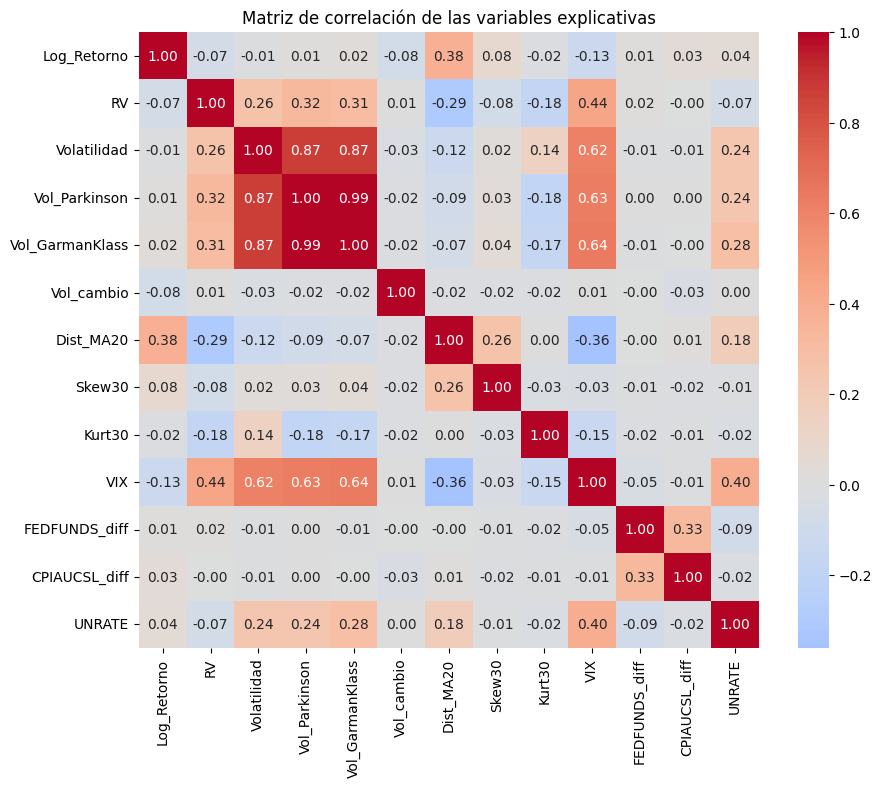

In [28]:
# Gráfico de matriz de correlación 

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlación de las variables explicativas")
plt.show()

Los diferentes rezagos de una misma variable suelen estar altamente correlacionados debido a su dependencia temporal, lo que puede generar problemas de multicolinealidad. Esta redundancia introduce información repetida y puede afectar el rendimiento de modelos sensibles a variables correlacionadas, como Support Vector Regression (SVR), dificultando su estimación. En cambio, Random Forest es mucho menos afectado por este problema, ya que cada árbol se construye utilizando subconjuntos aleatorios de variables y la predicción final se obtiene al combinar los resultados de múltiples árboles, disminuyendo el impacto de las variables redundantes.

### 2.3 Preparación de Datos

**(a)** Elimine los valores nulos generados por los rezagos y ventanas móviles (inicio y fin de la muestra por la ventana forward).

In [29]:
# Eliminar valores nulos

data = data.dropna()

(b) Divida los datos en entrenamiento/validación/prueba respetando el **orden temporal** (por ejemplo, 70/15/15). Explique por qué un train_test_split aleatorio sería metodológicamente incorrecto en este contexto.

In [30]:
# Tamaño del conjunto de datos
n = len(data)

# Índices de corte (70% entrenamiento, 15% validación, 15% prueba)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

# División temporal
train = data.iloc[:train_end]
valid = data.iloc[train_end:val_end]
test = data.iloc[val_end:]

print(f"Entrenamiento: {len(train)} observaciones ({len(train)/n:.1%})")
print(f"Validación:    {len(valid)} observaciones ({len(valid)/n:.1%})")
print(f"Prueba:        {len(test)} observaciones ({len(test)/n:.1%})")

# Variable objetivo
target = "RV"

# Variables predictoras
X_train = train.drop(columns=[target])
y_train = train[target]

X_valid = valid.drop(columns=[target])
y_valid = valid[target]

X_test = test.drop(columns=[target])
y_test = test[target]

Entrenamiento: 1361 observaciones (70.0%)
Validación:    292 observaciones (15.0%)
Prueba:        292 observaciones (15.0%)


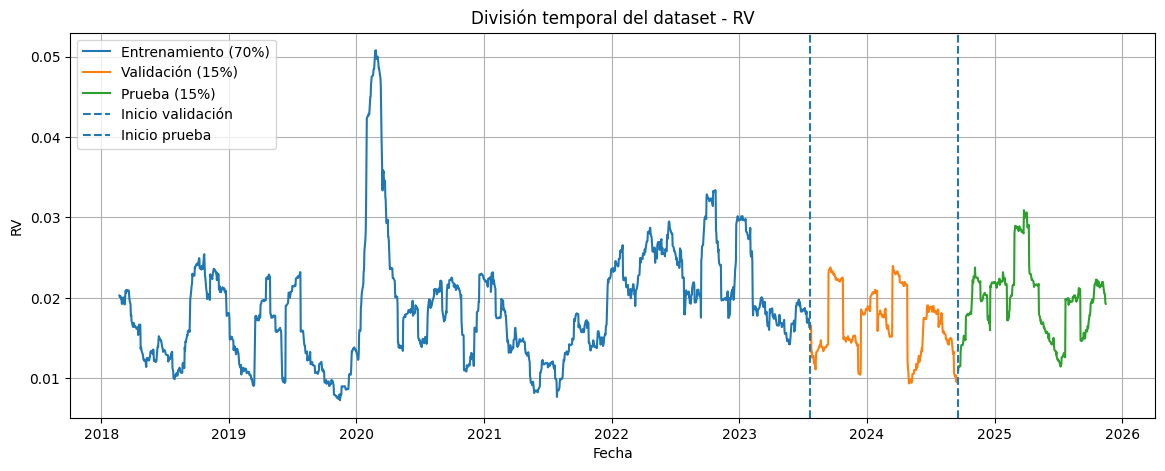

In [31]:
# Gráfico

plt.figure(figsize=(14,5))

plt.plot(y_train.index,y_train,label="Entrenamiento (70%)")
plt.plot(y_valid.index,y_valid,label="Validación (15%)")
plt.plot(y_test.index,y_test,label="Prueba (15%)")

# Líneas verticales de separación
plt.axvline(y_valid.index[0],linestyle="--",label="Inicio validación")
plt.axvline(y_test.index[0],linestyle="--",label="Inicio prueba")

plt.title(f"División temporal del dataset - {"RV"}")
plt.xlabel("Fecha")
plt.ylabel("RV")
plt.legend()
plt.grid(True)
plt.show()

Un train_test_split aleatorio sería metodológicamente incorrecto porque rompería la estructura temporal de los datos. En una serie financiera, las observaciones son secuenciales y la información disponible en un instante depende únicamente del pasado. Una división aleatoria mezclaría observaciones futuras con pasadas, permitiendo que el modelo se entrene con información que, en un escenario real de pronóstico, aún no estaría disponible (look-ahead bias). Esto produciría una evaluación demasiado optimista del desempeño del modelo y no reflejaría su capacidad para predecir datos verdaderamente futuros. Por ello, la partición debe realizarse respetando el orden cronológico: entrenamiento con las observaciones más antiguas, validación con un período posterior y prueba con las observaciones más recientes.

**(c)** Escale los features usando únicamente estadísticos calculados en el conjunto de entrenamiento (evite data leakage del conjunto de prueba hacia el scaler).

In [32]:
# Crear scaler de los features
scaler = StandardScaler()

# Ajustar SOLO con entrenamiento
scaler.fit(X_train)

# Transformar los datos de cada conjunto usando los estadísticos de entrenamiento
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_valid_scaled   = pd.DataFrame(scaler.transform(X_valid),   columns=X_valid.columns,   index=X_valid.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# Verificar que las dimensiones e índices se mantengan intactos
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_valid_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

X_train_scaled: (1361, 85)
X_val_scaled:   (292, 85)
X_test_scaled:  (292, 85)


### 2.4 Entrenamiento, Selección de Hiperparámetros y Modelos

(a) Entrene Random Forest y SVR (los modelos vistos en clases). Para la selección de hiperparámetros use TimeSeriesSplit (validación cruzada que respeta el orden temporal) combinado con GridSearchCV o RandomizedSearchCV — nunca k-fold estándar sobre series de tiempo. Reporte la grilla de hiperparámetros explorada para cada modelo.

In [33]:
# Configurar la validación cruzada respetando el orden temporal
tscv = TimeSeriesSplit(n_splits=5)

# ==========================================
# GRILLA DE HIPERPARÁMETROS: RANDOM FOREST
# ==========================================
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

# ==========================================
# GRILLA DE HIPERPARÁMETROS: SVR
# ==========================================
param_grid_svr = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'epsilon': [0.0001, 0.0005, 0.001, 0.005]  # Ajustado al rango de RV (~0.02)
}

In [34]:
# ------------------------------------------
# Entrenamiento de Random Forest
# ------------------------------------------
rf_base = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Entrenar únicamente con los datos de entrenamiento escalados/procesados
grid_rf.fit(X_train_scaled, y_train)

# Mejor modelo rf
best_rf = grid_rf.best_estimator_

# ------------------------------------------
# Entrenamiento de SVR
# ------------------------------------------
svr_base = SVR(kernel='rbf')

grid_svr = GridSearchCV(
    estimator=svr_base,
    param_grid=param_grid_svr,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_svr.fit(X_train_scaled, y_train)

# Mejor modelo svr
best_svr = grid_svr.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [35]:
print("==================================================")
print("REPORTE DE BÚSQUEDA DE HIPERPARÁMETROS")
print("==================================================\n")

print("--- 1. RANDOM FOREST ---")
print("Grilla explorada:")
for k, v in param_grid_rf.items():
    print(f"  - {k}: {v}")
print(f"\nMejores hiperparámetros encontrados:")
print(f"  {grid_rf.best_params_}")
print(f"Mejor MSE (Validación Cruzada): {-grid_rf.best_score_:.6f}\n")

print("--- 2. SUPPORT VECTOR REGRESSION (SVR) ---")
print("Grilla explorada:")
for k, v in param_grid_svr.items():
    print(f"  - {k}: {v}")
print(f"\nMejores hiperparámetros encontrados:")
print(f"  {grid_svr.best_params_}")
print(f"Mejor MSE (Validación Cruzada): {-grid_svr.best_score_:.6f}")

REPORTE DE BÚSQUEDA DE HIPERPARÁMETROS

--- 1. RANDOM FOREST ---
Grilla explorada:
  - n_estimators: [100]
  - max_depth: [3, 5, 10, None]
  - min_samples_split: [2, 5, 10]
  - min_samples_leaf: [1, 2, 4]
  - max_features: ['sqrt', 'log2', 1.0]

Mejores hiperparámetros encontrados:
  {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Mejor MSE (Validación Cruzada): 0.000016

--- 2. SUPPORT VECTOR REGRESSION (SVR) ---
Grilla explorada:
  - C: [0.1, 1, 10, 100]
  - gamma: ['scale', 'auto', 0.001, 0.01, 0.1]
  - epsilon: [0.0001, 0.0005, 0.001, 0.005]

Mejores hiperparámetros encontrados:
  {'C': 1, 'epsilon': 0.0001, 'gamma': 0.001}
Mejor MSE (Validación Cruzada): 0.000004


**(b)** (Extensión) Entrene además un modelo de **Gradient Boosting** (XGBoost, LightGBM o GradientBoostingRegressor) como tercer competidor de machine learning.

In [36]:
# Definir la grilla de hiperparámetros para Gradient Boosting
param_grid_gb = {
    'n_estimators': [50, 100],          # Número de árboles sucesivos
    'learning_rate': [0.01, 0.05, 0.1],  # Tasa de aprendizaje (shrinkage)
    'max_depth': [3, 5],                 # Profundidad de cada árbol (suelen ser árboles más cortos)
    'subsample': [0.8, 1.0],             # Fracción de muestras usadas para entrenar cada árbol
    'max_features': ['sqrt', 1.0]        # Fracción de variables por corte
}

# Configurar la validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

# Instanciar el modelo base
gb_base = GradientBoostingRegressor(random_state=42)

# Configurar GridSearchCV
grid_gb = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid_gb,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Ajustar únicamente sobre los datos de entrenamiento
grid_gb.fit(X_train_scaled, y_train)

# Mejor modelo encontrado
best_gbr = grid_gb.best_estimator_

# Reportar los mejores resultados
print("GRADIENT BOOSTING - MEJORES HIPERPARÁMETROS")
print("==================================================")
print(f"Mejores hiperparámetros: {grid_gb.best_params_}")
print(f"Mejor MSE (Validación Cruzada): {-grid_gb.best_score_:.6f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
GRADIENT BOOSTING - MEJORES HIPERPARÁMETROS
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 1.0, 'n_estimators': 100, 'subsample': 1.0}
Mejor MSE (Validación Cruzada): 0.000017


Este modelo permite comparar tres enfoques distintos:

Random Forest: ensamble de árboles con reducción de varianza, robusto ante ruido y multicolinealidad.
SVR: modelo basado en margen, sensible a escalamiento y correlación entre variables.
Gradient Boosting: ensamble secuencial donde cada árbol corrige los errores del anterior, generalmente con mayor capacidad predictiva pero mayor riesgo de sobreajuste si la regularización es insuficiente.

**(c)** Reporte la importancia de variables (impureza para Random Forest/GBM, y permutation importance — válida para los tres modelos, incluyendo SVR) de cada modelo ganador. ¿Dominan los rezagos de volatilidad propia, el VIX, o las variables macro? Comente si esto es consistente con la teoría financiera de volatility clustering.

Para analizar la relevancia de los predictores de cada modelo ganador, se pueden utilizar dos enfoques complementarios:

Importancia por impureza (feature_importances_): disponible para modelos basados en árboles como Random Forest y Gradient Boosting. Mide cuánto contribuye cada variable a reducir la impureza promedio de los árboles.
Permutation importance: aplicable a los tres modelos (Random Forest, Gradient Boosting y SVR). Evalúa cuánto empeora el desempeño del modelo cuando se permuta aleatoriamente una variable, destruyendo su relación con la variable objetivo.

In [37]:
# IMPORTANCIA BASADA EN IMPUREZA (Gini / MDI) para RF y GBM
imp_rf_impurity  = pd.Series(grid_rf.best_estimator_.feature_importances_, index=X_train.columns).sort_values(ascending=False)
imp_gb_impurity  = pd.Series(grid_gb.best_estimator_.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# PERMUTATION IMPORTANCE (Válida para RF, GBM y SVR)
# Evaluamos sobre el conjunto de validación para medir impacto out-of-sample
perm_rf  = permutation_importance(grid_rf.best_estimator_, X_valid_scaled, y_valid, n_repeats=10, random_state=42)
perm_gb  = permutation_importance(grid_gb.best_estimator_, X_valid_scaled, y_valid, n_repeats=10, random_state=42)
perm_svr = permutation_importance(grid_svr.best_estimator_, X_valid_scaled, y_valid, n_repeats=10, random_state=42)

# Convertir a Series para fácil visualización
perm_rf_series  = pd.Series(perm_rf.importances_mean, index=X_train.columns)
perm_gb_series  = pd.Series(perm_gb.importances_mean, index=X_train.columns)
perm_svr_series = pd.Series(perm_svr.importances_mean, index=X_train.columns)

# Consolidar en un solo DataFrame
importancias_df = pd.DataFrame({
    'RF_Impurity': imp_rf_impurity,
    'RF_Permutation': perm_rf_series,
    'GBM_Impurity': imp_gb_impurity,
    'GBM_Permutation': perm_gb_series,
    'SVR_Permutation': perm_svr_series
}).sort_values(by='RF_Permutation', ascending=False)

print(importancias_df)

                        RF_Impurity  RF_Permutation  GBM_Impurity  \
Lag_RV_1                   0.974933        1.943345      0.979125   
Log_Retorno                0.002929        0.019560      0.005510   
Volume                     0.001115        0.001830      0.000902   
Vol_cambio                 0.000799        0.001439      0.000319   
Lag_RV_5                   0.002442        0.000864      0.000500   
...                             ...             ...           ...   
Lag_Vol_Parkinson_2        0.000164       -0.001217      0.000072   
Lag_Vol_Garman_Klass_2     0.000089       -0.001248      0.000022   
Lag_Vol_Garman_Klass_3     0.000473       -0.001276      0.000062   
Kurt30                     0.000425       -0.003104      0.000259   
Lag_Volatility_3           0.000439       -0.005301      0.000143   

                        GBM_Permutation  SVR_Permutation  
Lag_RV_1                       1.827706         1.800837  
Log_Retorno                    0.040957         0.036

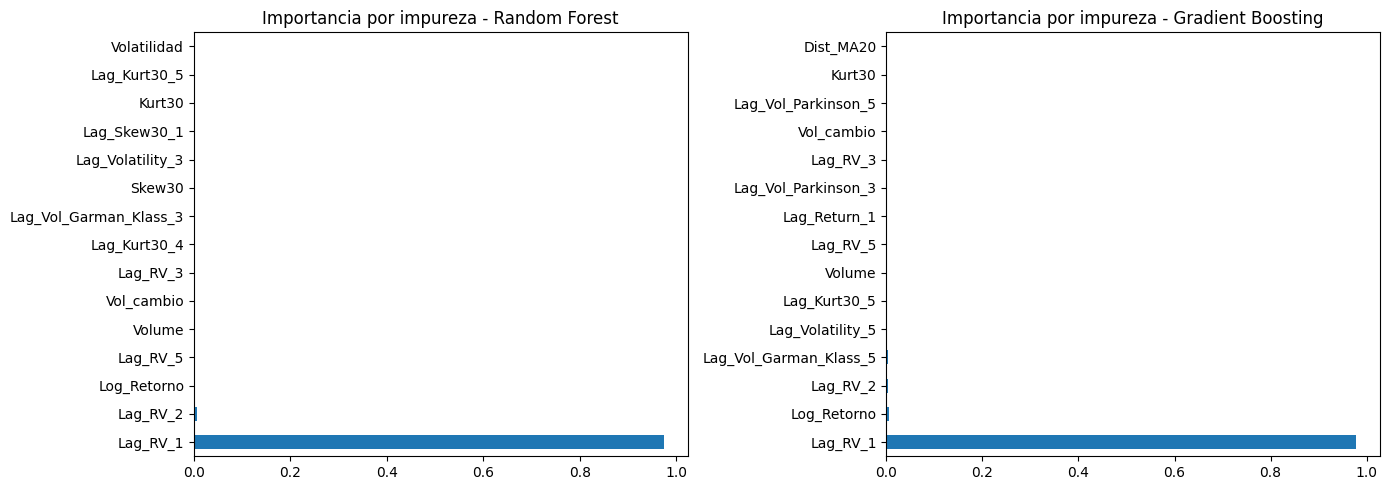

In [38]:
# Gráfico Importancia por impureza: Random Forest y Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(14,5))

imp_rf_impurity.head(15).plot(kind="barh",ax=axes[0],title="Importancia por impureza - Random Forest")
imp_gb_impurity.head(15).plot(kind="barh",ax=axes[1],title="Importancia por impureza - Gradient Boosting")

plt.tight_layout()
plt.show()

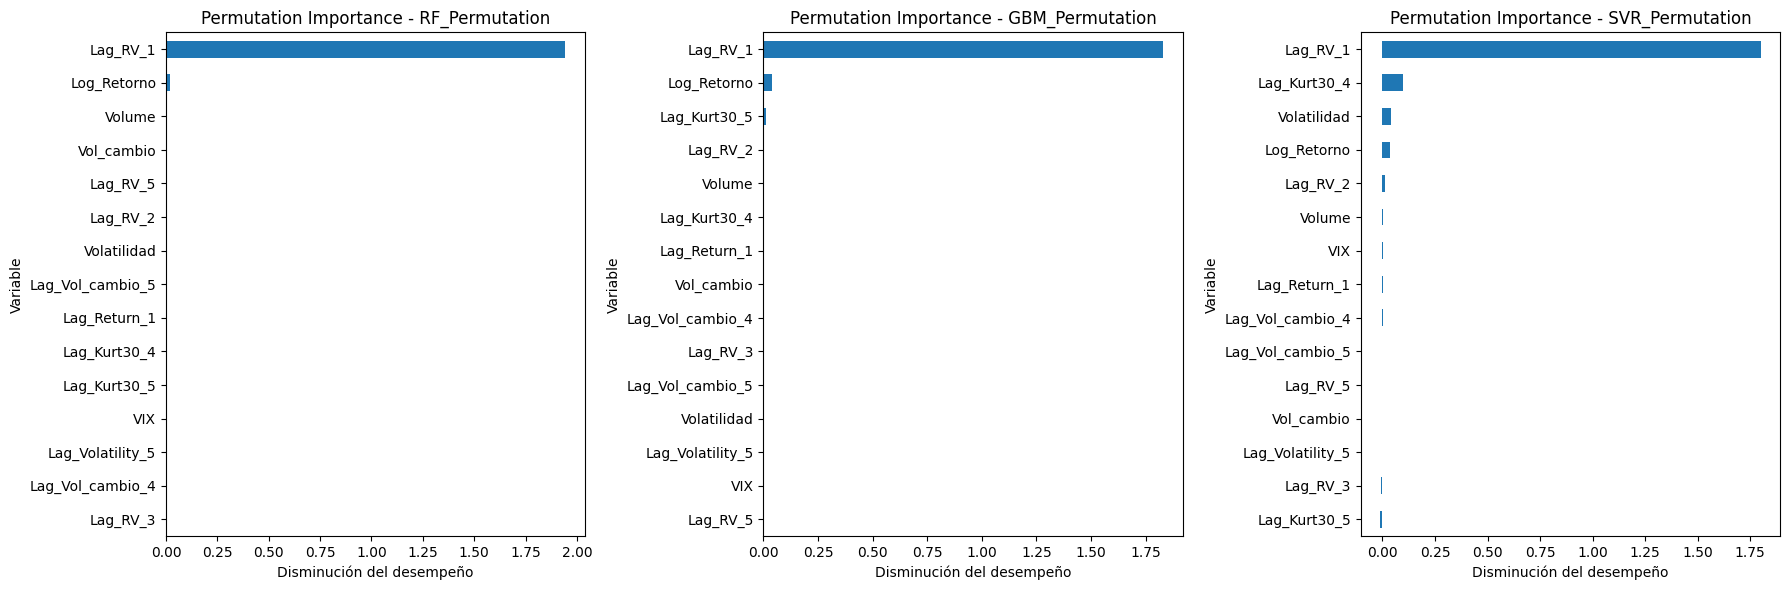

In [39]:
# Gráfico Permutation Importance para los tres modelos

permutation_models = importancias_df[['RF_Permutation', 'GBM_Permutation', 'SVR_Permutation']]

# Seleccionar las 15 variables más importantes según RF
top_features = importancias_df.sort_values(by="RF_Permutation",ascending=False).head(15).index

fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, model in zip(axes, permutation_models.columns):
    
    permutation_models.loc[top_features, model].sort_values().plot(kind="barh",ax=ax)
    
    ax.set_title(f"Permutation Importance - {model}")
    ax.set_xlabel("Disminución del desempeño")
    ax.set_ylabel("Variable")

plt.tight_layout()
plt.show()

La importancia por impureza muestra que, tanto en Random Forest como en Gradient Boosting, la variable Lag_RV_1 (volatilidad realizada del período anterior) concentra casi toda la importancia para realizar las predicciones. En cambio, el resto de las variables presenta una contribución muy baja o prácticamente nula. Esto indica que ambos modelos dependen principalmente del comportamiento reciente de la volatilidad, mientras que las demás variables aportan poca información adicional para mejorar el pronóstico. Además, el patrón es más marcado en Gradient Boosting, donde la importancia está aún más concentrada en Lag_RV_1. En conjunto, estos resultados son consistentes con la elevada persistencia temporal que caracteriza a la volatilidad de los mercados financieros, donde el comportamiento reciente constituye el principal determinante de la volatilidad futura.

La importancia por permutación revela un patrón consistente entre los tres modelos, evidenciando que la predicción de la volatilidad depende principalmente del primer rezago de la volatilidad realizada (Lag_RV_1). Si bien SVR distribuye la importancia entre un mayor número de rezagos, Gradient Boosting y especialmente Random Forest, concentran la mayor parte de su capacidad predictiva en Lag_RV_1. En contraste, el resto de los predictores presentan una contribución marginal, lo que indica que aportan escasa información adicional una vez incorporada la historia reciente de la volatilidad. Estos resultados refuerzan la evidencia de la elevada persistencia temporal característica de la volatilidad en los mercados financieros.

### 2.5 Evaluación y Comparación de Desempeño


**(a)** Evalúe cada modelo en el conjunto de prueba utilizando las métricas **RMSE, MAE y QLIKE**. Esta última corresponde a la función de pérdida estándar en la literatura de *forecasting* de volatilidad, $\text{QLIKE}=\frac{1}{n}\sum_{t=1}^{n}\left(\frac{\text{RV}_t}{\hat{\sigma}_t^{2}}-\ln\left(\frac{\text{RV}_t}{\hat{\sigma}_t^{2}}\right)-1\right),$ y es más robusta a la asimetría de la distribución de la volatilidad que el RMSE.  

(b) Grafique la volatilidad observada vs. la volatilidad estimada por cada modelo en el conjunto de prueba, en un mismo panel para facilitar la comparación visual.

In [40]:
# Evaluación de modelos con RMSE, MAE y QLIKE

# Definición de la función de pérdida QLIKE
def qlike_loss(y_true, y_pred):
    """
    Calcula la función de pérdida QLIKE.
    y_true: Valores reales de volatilidad (RV_t)
    y_pred: Predicciones del modelo (sigma_hat^2_t)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Evitar divisiones por cero o valores <= 0 en el logaritmo
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, None)
    
    ratio = y_true / y_pred
    loss = np.mean(ratio - np.log(ratio) - 1)
    return loss

# Generar predicciones en el conjunto de prueba para cada modelo
pred_rf  = best_rf.predict(X_test_scaled)
pred_gb  = best_gbr.predict(X_test_scaled)
pred_svr = best_svr.predict(X_test_scaled)

# Función auxiliar para consolidar las 3 métricas
def evaluar_modelo(y_true, y_pred):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    qlike = qlike_loss(y_true, y_pred)
    return rmse, mae, qlike

# Construcción de la tabla de resultados
metricas = {
    'Random Forest': evaluar_modelo(y_test, pred_rf),
    'Gradient Boosting': evaluar_modelo(y_test, pred_gb),
    'SVR': evaluar_modelo(y_test, pred_svr)
}

df_resultados = pd.DataFrame(
    metricas, 
    index=['RMSE', 'MAE', 'QLIKE']
).T

print("=== EVALUACIÓN EN EL CONJUNTO DE PRUEBA (TEST SET) ===")
print(df_resultados.round(6))

=== EVALUACIÓN EN EL CONJUNTO DE PRUEBA (TEST SET) ===
                       RMSE       MAE     QLIKE
Random Forest      0.000943  0.000491  0.001338
Gradient Boosting  0.000861  0.000437  0.001130
SVR                0.001722  0.001341  0.003816


Los resultados muestran que los modelos de ensamble basados en árboles obtienen un mejor desempeño que SVR en la predicción de la volatilidad realizada. Gradient Boosting presenta los menores valores de RMSE y MAE, lo que indica una mayor precisión en las predicciones. Por su parte, Random Forest obtiene el mejor resultado en la métrica QLIKE, la cual es ampliamente utilizada para evaluar pronósticos de volatilidad financiera. En conjunto, ambos modelos ofrecen un buen rendimiento, aunque Random Forest puede ser la mejor alternativa cuando se busca reducir los errores relativos en la estimación de la varianza.

**(b)** Grafique la volatilidad observada vs. la volatilidad estimada por cada modelo en el conjunto de prueba, en un mismo panel para facilitar la comparación visual.

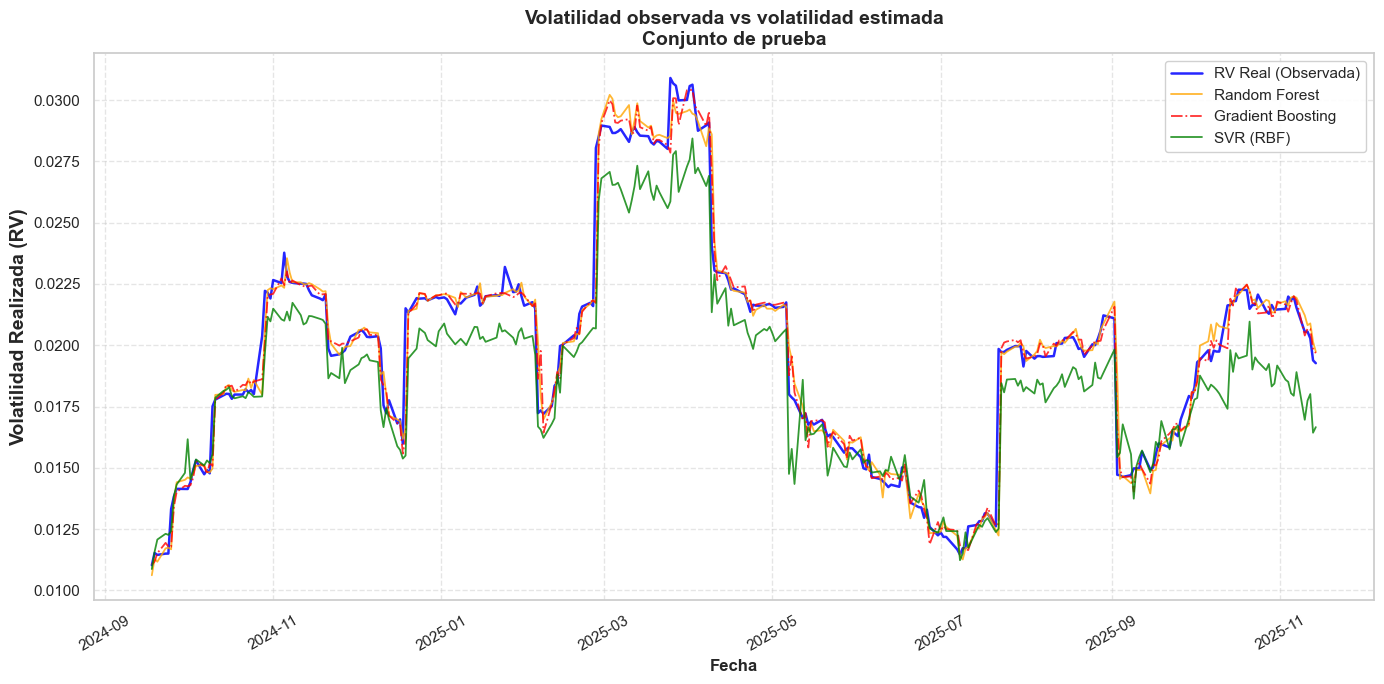

In [41]:
# Gráfico volatilidad observada vs estimada

# Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Graficar la Volatilidad Real (Observada)
plt.plot(X_test.index, y_test, label='RV Real (Observada)', color='blue', linewidth=1.8, alpha=0.85)

# 2. Graficar las Predicciones de cada Modelo
plt.plot(X_test.index, pred_rf, label='Random Forest', color='orange', linewidth=1.3, linestyle='-', alpha=0.8)
plt.plot(X_test.index, pred_gb, label='Gradient Boosting', color='red', linewidth=1.3, linestyle='-.', alpha=0.8)
plt.plot(X_test.index, pred_svr, label='SVR (RBF)', color='green', linewidth=1.3, linestyle='-', alpha=0.8)

# 3. Personalización del Gráfico
plt.title("Volatilidad observada vs volatilidad estimada\nConjunto de prueba", fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12, fontweight='bold')
plt.ylabel('Volatilidad Realizada (RV)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar rotación de fechas en el eje X para mejorar la lectura
plt.xticks(rotation=30)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### 2.6 Benchmark contra Modelos Econométricos

**(a)** Ajuste modelos GARCH(1,1) y EGARCH(1,1) (vistos en clases) sobre los retornos de la misma acción, y genere pronósticos de volatilidad fuera de muestra alineados temporalmente con el mismo período de prueba usado para los modelos de ML (use un esquema rolling/expanding window explícito y consistente con el usado, si corresponde, en la sección de series de tiempo).

In [ ]:
# 1. ALINEACIÓN TEMPORAL Y ESCALAMIENTO
# ==============================================================================
# Extraemos las fechas del conjunto de prueba usado en los modelos de ML
test_index = X_test.index
n_test = len(test_index)

# Serie de retornos logarítmicos alineada con el DataFrame
returns_series = data.loc[data.index, "Log_Retorno"] * 100

# Posición donde inicia el conjunto de prueba
start_loc = len(returns_series) - n_test

# Arreglos para almacenar las varianzas pronosticadas a 1 paso adelante
var_pred_garch = np.zeros(n_test)
var_pred_egarch = np.zeros(n_test)

# 2. BUCLE EXPANDING WINDOW (1-STEP-AHEAD FORECASTING)
# ==============================================================================
print(f"Iniciando estimación fuera de muestra ({n_test} observaciones)...")

for i in range(n_test):
    # La muestra de entrenamiento se expande hasta t - 1
    train_returns = returns_series.iloc[:start_loc + i]
    
    # --------------------------------------------------------------------------
    # A. Modelo GARCH(1,1)
    # --------------------------------------------------------------------------
    model_garch = arch_model(train_returns, p=1, q=1, vol='GARCH', dist='normal')
    res_garch = model_garch.fit(disp='off')
    
    # Pronóstico de varianza a 1 paso
    f_garch = res_garch.forecast(horizon=1)
    var_pred_garch[i] = f_garch.variance.iloc[-1, 0]
    
    # --------------------------------------------------------------------------
    # B. Modelo EGARCH(1,1)
    # --------------------------------------------------------------------------
    model_egarch = arch_model(train_returns, p=1, q=1, vol='EGARCH', dist='normal')
    res_egarch = model_egarch.fit(disp='off')
    
    # Pronóstico de varianza a 1 paso
    f_egarch = res_egarch.forecast(horizon=1)
    var_pred_egarch[i] = f_egarch.variance.iloc[-1, 0]

# 3. CONVERSIÓN A DESVIACIÓN ESTÁNDAR (ESCALA ORIGINAL DE RV)
# ==============================================================================

pred_garch_rv = pd.Series(np.sqrt(var_pred_garch) / 100, index=test_index)
pred_egarch_rv = pd.Series(np.sqrt(var_pred_egarch) / 100, index=test_index)

print("Proceso finalizado, Pronósticos terminados.")

Iniciando estimación fuera de muestra (292 observaciones)...
¡Proceso finalizado! Pronósticos econométricos listos.


**(b)** Compare RMSE, MAE y QLIKE de los cuatro-cinco modelos (RF, SVR, [GBM], GARCH, EGARCH) en una tabla resumen ordenada por desempeño.

In [43]:
# Definición de la función QLIKE
def qlike_loss(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

# Función para calcular todas las métricas de un modelo
def calcular_metricas(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    qlike = qlike_loss(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'QLIKE': qlike}

# Diccionario con todas las predicciones sobre el conjunto de prueba
diccionario_predicciones = {
    'Random Forest': pred_rf,
    'Gradient Boosting (GBM)': pred_gb,
    'SVR': pred_svr,
    'GARCH(1,1)': pred_garch_rv,
    'EGARCH(1,1)': pred_egarch_rv
}

# Construcción de la tabla de resultados
resultados = []
for nombre_modelo, y_pred in diccionario_predicciones.items():
    m = calcular_metricas(y_test, y_pred)
    m['Modelo'] = nombre_modelo
    resultados.append(m)

# Crear DataFrame y reordenar columnas
df_resumen = pd.DataFrame(resultados)[['Modelo', 'QLIKE', 'RMSE', 'MAE']]

# Ordenar por la métrica principal en literatura de volatilidad (QLIKE ascendente)
df_resumen = df_resumen.sort_values(by='QLIKE', ascending=True).reset_index(drop=True)

# Imprimir tabla formateada
print("=== Tabla comparativa de desempeño en el conjunto de prueba ===")
print(df_resumen.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

=== Tabla comparativa de desempeño en el conjunto de prueba ===
                 Modelo    QLIKE     RMSE      MAE
Gradient Boosting (GBM) 0.001130 0.000861 0.000437
          Random Forest 0.001338 0.000943 0.000491
                    SVR 0.003816 0.001722 0.001341
            EGARCH(1,1) 0.030386 0.004822 0.004238
             GARCH(1,1) 0.032854 0.005126 0.004428


**(c)** Aplique el test de Diebold-Mariano para determinar si la diferencia de desempeño entre el mejor modelo de ML y el mejor modelo GARCH/EGARCH es estadísticamente significativa, o si podría deberse a ruido muestral.

In [44]:
def diebold_mariano_test(y_true, y_pred1, y_pred2, h=1):
    """
    Realiza el test de Diebold-Mariano usando la función de pérdida QLIKE.
    
    y_true: Volatilidad real observada
    y_pred1: Predicciones del Modelo 1 (ej. Mejor ML)
    y_pred2: Predicciones del Modelo 2 (ej. Mejor EGARCH/GARCH)
    h: Horizonte de pronóstico (por defecto 1)
    """
    y_true = np.array(y_true)
    y_pred1 = np.array(y_pred1)
    y_pred2 = np.array(y_pred2)
    eps = 1e-8
    
    # 1. Calcular pérdidas QLIKE individuales para cada punto en el tiempo
    loss1 = (y_true / np.clip(y_pred1, eps, None)) - np.log((y_true / np.clip(y_pred1, eps, None))) - 1
    loss2 = (y_true / np.clip(y_pred2, eps, None)) - np.log((y_true / np.clip(y_pred2, eps, None))) - 1
    
    # 2. Diferencial de pérdida: d_t = Loss(Modelo 1) - Loss(Modelo 2)
    d = loss1 - loss2
    d_bar = np.mean(d)
    T = len(d)
    
    # 3. Estimación de varianza con autocovarianza (Ajuste Newey-West / HAC)
    # Autocovarianza a lag 0
    gamma_0 = np.var(d, ddof=0)
    
    # Suma de autocovarianzas ponderadas hasta el lag (h - 1)
    gamma_sum = 0
    for k in range(1, h):
        gamma_k = np.cov(d[:-k], d[k:], ddof=0)[0, 1]
        weight = 1 - (k / h) # Ponderador de Bartlett
        gamma_sum += weight * gamma_k
        
    var_d = (gamma_0 + 2 * gamma_sum) / T
    
    # 4. Estadístico DM (distribuido asintóticamente como N(0,1))
    DM_stat = d_bar / np.sqrt(var_d)
    
    # Corrección para muestras finitas de Harvey, Leybourne y Newbold (HLN)
    HLN_factor = np.sqrt((T + 1 - 2*h + (h/T)*(h - 1)) / T)
    DM_stat_corrected = DM_stat * HLN_factor
    
    # p-valor bilateral (two-tailed test)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(DM_stat_corrected)))
    
    return DM_stat_corrected, p_value

In [45]:
# APLICACIÓN DEL TEST ENTRE Gradient Boosting vs GARCH

dm_stat, p_val = diebold_mariano_test(y_test, pred_gb, pred_garch_rv, h=1)

print("=== TEST DE DIEBOLD-MARIANO (PÉRDIDA QLIKE) Gradient Boosting vs GARCH ===")
print(f"Estadístico DM: {dm_stat:.4f}")
print(f"p-valor:        {p_val:.6f}")

if p_val < 0.05:
    print("\nConclusión: Se RECHAZA la hipótesis nula ($H_0$) con un 95% de confianza.")
    print("La diferencia de desempeño entre Gradient Boosting y GARCH ES estadísticamente significativa.")
else:
    print("\nConclusión: NO se rechaza la hipótesis nula ($H_0$).")
    print("La diferencia de desempeño podría deberse únicamente a ruido muestral.")

=== TEST DE DIEBOLD-MARIANO (PÉRDIDA QLIKE) Gradient Boosting vs GARCH ===
Estadístico DM: -17.3631
p-valor:        0.000000

Conclusión: Se RECHAZA la hipótesis nula ($H_0$) con un 95% de confianza.
La diferencia de desempeño entre Gradient Boosting y GARCH ES estadísticamente significativa.


In [46]:
# APLICACIÓN DEL TEST ENTRE Gradient Boosting vs EGARCH

dm_stat, p_val = diebold_mariano_test(y_test, pred_gb, pred_egarch_rv, h=1)

print("=== TEST DE DIEBOLD-MARIANO (PÉRDIDA QLIKE) Gradient Boosting vs EGARCH ===")
print(f"Estadístico DM: {dm_stat:.4f}")
print(f"p-valor:        {p_val:.6f}")

if p_val < 0.05:
    print("\nConclusión: Se RECHAZA la hipótesis nula ($H_0$) con un 95% de confianza.")
    print("La diferencia de desempeño entre Gradient Boosting y EGARCH ES estadísticamente significativa.")
else:
    print("\nConclusión: NO se rechaza la hipótesis nula ($H_0$).")
    print("La diferencia de desempeño podría deberse únicamente a ruido muestral.")

=== TEST DE DIEBOLD-MARIANO (PÉRDIDA QLIKE) Gradient Boosting vs EGARCH ===
Estadístico DM: -17.7955
p-valor:        0.000000

Conclusión: Se RECHAZA la hipótesis nula ($H_0$) con un 95% de confianza.
La diferencia de desempeño entre Gradient Boosting y EGARCH ES estadísticamente significativa.


El test de Diebold-Mariano evalúa la hipótesis nula:

$$H_0: E(d_t) = 0$$

donde $d_t$ representa la diferencia entre las pérdidas de pronóstico de ambos modelos utilizando la función QLIKE.

En ambos casos se obtiene un **p-value igual a 0**, por lo que se rechaza la hipótesis nula al 5% de nivel de significancia. Esto indica que la diferencia de desempeño entre **Gradient Boosting** y los modelos **GARCH/EGARCH** es estadísticamente significativa y no puede atribuirse solamente a ruido muestral.

El estadístico $DM$ es negativo en ambas comparaciones:

* $DM_{\text{GBM}-\text{GARCH}} = -17.3631$
* $DM_{\text{GBM}-\text{EGARCH}} = -17.7955$

Dado que la diferencia se definió como:

$$d_t = L_{\text{GBM},t} - L_{\text{GARCH},t}$$

un valor negativo implica que la pérdida promedio del modelo **Gradient Boosting** es menor que la del modelo **GARCH/EGARCH**. Por lo tanto, el signo del estadístico confirma que **GBM presenta un mejor desempeño predictivo**.

### 2.7 Diagnóstico de Errores

Para el modelo ganador (según 2.6b), analice los errores de predicción **$(\text{RV}_t - \hat{\text{RV}}_t)$** en el conjunto de prueba: grafíquelos en el tiempo, evalúe si están correlacionados serialmente (ACF) y si su magnitud se relaciona con períodos de alta volatilidad de mercado (por ejemplo, marcando visualmente eventos de estrés conocidos dentro de su ventana de prueba, si los hay).

In [47]:
# Error de predicción

errores = y_test - pred_gb  # RV_t - RV_hat_t

# Crear un DataFrame
df_errores = pd.DataFrame({
    'RV_real': y_test,
    'RV_pred': pred_gb,
    'Error': errores,
    'Error_Absoluto': np.abs(errores)
}, index=X_test.index)

**Periodo de estrés conjunto de prueba** : Para Google entre 2018-2025, un evento dentro del conjunto de prueba es:

-Diciembre 2024:Lanzamiento de Gemini 2.0.

-Frebro Marzo: Informes presentaron cifras del cuarto trimestre que mostraron un crecimiento menor al esperado en algunos segmentos.

-Abril 2025: aumento de volatilidad por anuncios arancelarios y tensiones comerciales.

-Julio 2025: Reportes sólidos de utilidad del segundo semestre

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jeloy\AppData\Local\Temp\ipykernel_10984\1712272456.py:11: SyntaxWarning: invalid escape sequence '\h'
  label="Error ($RV_t - \hat{RV}_t$)",
C:\Users\jeloy\AppData\Local\Temp\ipykernel_10984\1712272456.py:23: SyntaxWarning: invalid escape sequence '\h'
  "Errores de Predicción en el Tiempo ($RV_t - \hat{RV}_t$)",


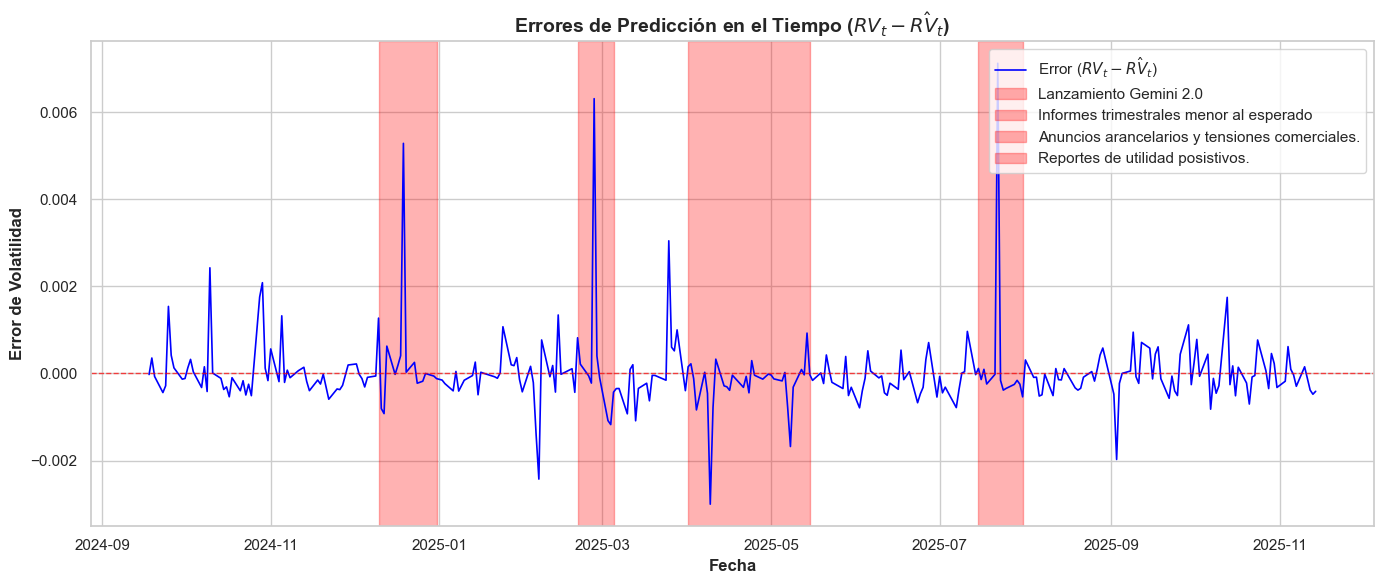

In [60]:
# Gráfico de errores en el tiempo y eventos de estrés
# ==============================================================================
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

plt.plot(
    df_errores.index,
    df_errores["Error"],
    color="blue",
    linewidth=1.2,
    label="Error ($RV_t - \hat{RV}_t$)",
)
plt.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)

# --- Sombreado de Eventos de Estrés (Fuera del bucle) ---
plt.axvspan(pd.Timestamp("2024-12-10"),pd.Timestamp("2024-12-31"),color="red",alpha=0.3,label="Lanzamiento Gemini 2.0",)
plt.axvspan(pd.Timestamp("2025-02-20"),pd.Timestamp("2025-03-05"),color="red",alpha=0.3,label="Informes trimestrales menor al esperado",)
plt.axvspan(pd.Timestamp("2025-04-01"),pd.Timestamp("2025-05-15"),color="red",alpha=0.3,label="Anuncios arancelarios y tensiones comerciales.",)
plt.axvspan(pd.Timestamp("2025-07-15"),pd.Timestamp("2025-07-31"),color="red",alpha=0.3,label="Reportes de utilidad posistivos.",)


plt.title(
    "Errores de Predicción en el Tiempo ($RV_t - \hat{RV}_t$)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Fecha", fontsize=12, fontweight="bold")
plt.ylabel("Error de Volatilidad", fontsize=12, fontweight="bold")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Según la imagen no existe autocorrelación significativa, los errores se comportan aproximadamente como ruido blanco por lo que el modelo captura adecuadamente la dinámica temporal.

<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jeloy\AppData\Local\Temp\ipykernel_10984\2465127790.py:15: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_ylabel('Error Absoluto (|\hat{e}_t|)', fontsize=10)


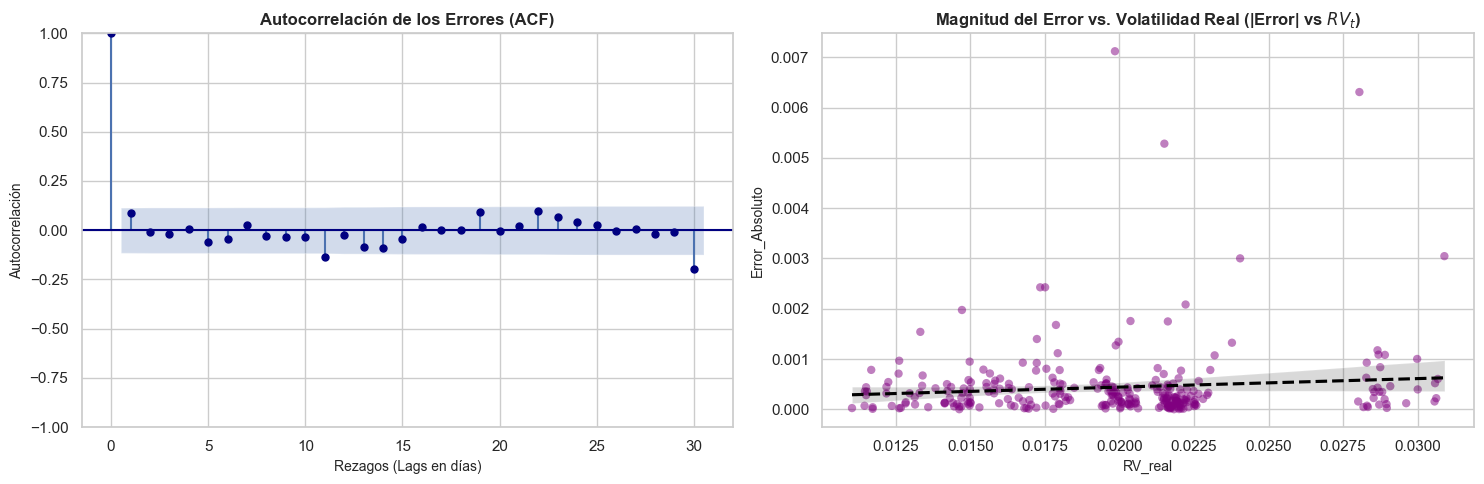

In [61]:
# 3. GRÁFICO 2: AUTOCORRELACIÓN DE ERRORES (ACF) Y RELACIÓN CON LA VOLATILIDAD
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot A: Función de Autocorrelación (ACF) de los errores
plot_acf(df_errores['Error'], lags=30, ax=axes[0], alpha=0.05, color='navy')
axes[0].set_title('Autocorrelación de los Errores (ACF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rezagos (Lags en días)', fontsize=10)
axes[0].set_ylabel('Autocorrelación', fontsize=10)

# Subplot B: Magnitud del Error vs Nivel de Volatilidad Real
axes[1].scatter(df_errores['RV_real'], df_errores['Error_Absoluto'], color='purple', alpha=0.5, edgecolors='none')
axes[1].set_title('Magnitud del Error vs. Volatilidad Real (|Error| vs $RV_t$)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volatilidad Real ($RV_t$)', fontsize=10)
axes[1].set_ylabel('Error Absoluto (|\hat{e}_t|)', fontsize=10)

# Línea de tendencia lineal para evidenciar heterocedasticidad
sns.regplot(x='RV_real', y='Error_Absoluto', data=df_errores, ax=axes[1], scatter=False, color='black', line_kws={'linestyle':'--'})

plt.tight_layout()
plt.show()

Los errores de predicción del modelo Gradient Boosting se definieron como **$(\text{RV}_t - \hat{\text{RV}}_t)$**. La serie de errores fluctúa alrededor de cero, sin evidenciar sesgos sistemáticos de sobreestimación o subestimación. Además, la ACF no muestra autocorrelaciones significativas, lo que indica que los errores se comportan aproximadamente como ruido blanco.

El gráfico de la magnitud del error evidencia presencia de heterocedasticidad en los errores, ya que la dispersión aumenta a medida que crece la volatilidad realizada. En períodos de baja volatilidad, los errores son pequeños y el modelo presenta un comportamiento estable. Sin embargo, en escenarios de mayor volatilidad aparecen errores más elevados y valores atípicos, indicando una menor precisión durante episodios de estrés de mercado.

Además, la pendiente levemente positiva de la línea de tendencia sugiere una relación directa entre la volatilidad y el error de predicción: a mayores niveles de volatilidad, mayor es la magnitud esperada del error.

### 2.8 Discusión Final

Responda de forma breve y argumentada: 


**1.** ¿El mejor modelo de machine learning supera de forma estadísticamente significativa a los benchmarks GARCH/EGARCH? Si no es así, ¿qué tan justificable es, en la práctica, preferir un modelo de caja negra sobre uno econométrico interpretable con desempeño similar?

El modelo Gradient Boosting obtuvo un mejor desempeño que GARCH(1,1) y EGARCH(1,1), lo que fue confirmado por el test de Diebold-Mariano, cuyos p-values fueron iguales a cero. Esto indica que la diferencia entre los modelos es estadísticamente significativa y no se debe al azar. Si los modelos hubieran presentado resultados similares, la elección dependería del objetivo del estudio. Los modelos GARCH ofrecen mayor interpretación económica de la volatilidad, mientras que los modelos de machine learning son más adecuados para capturar relaciones no lineales y patrones más complejos en los datos.

**2.** ¿Qué variables resultaron más relevantes según la importancia de features, y es consistente con lo que un modelo GARCH asume implícitamente (que el mejor predictor de la volatilidad futura es la volatilidad/los choques pasados)?

Las variables más importantes fueron los rezagos de la volatilidad realizada y de los retornos históricos, lo que demuestra que la información pasada es clave para predecir la volatilidad futura. Este resultado coincide con la lógica de los modelos GARCH, que explican la volatilidad a partir de su comportamiento histórico y de los shocks anteriores. Sin embargo, los modelos de machine learning tienen la ventaja de detectar relaciones no lineales y patrones complejos entre varias variables, sin necesidad de definir previamente una estructura específica del modelo.

**3.** Mencione al menos dos limitaciones del enfoque de ML utilizado para pronóstico de volatilidad financiera (por ejemplo, incapacidad de extrapolar fuera del rango de entrenamiento, ausencia de una dinámica de reversión a la media explícita, riesgo de sobreajuste con el número de features/rezagos utilizados) y cómo las abordaría en una extensión futura (por ejemplo, modelos híbridos ML-GARCH, LSTM, o ensemble de ambos enfoques)

Una de las principales limitaciones de los modelos de machine learning es que pueden tener dificultades para predecir períodos de volatilidad extrema que no estuvieron presentes en los datos de entrenamiento, ya que aprenden a partir de patrones históricos. Además, incluir un número elevado de rezagos puede aumentar la complejidad del modelo y favorecer el sobreajuste, reduciendo su capacidad de generalizar a nuevos datos.

Como trabajo futuro, se podría desarrollar un modelo híbrido ML-GARCH, donde el modelo GARCH represente la persistencia y la dinámica de la volatilidad, mientras que el modelo de machine learning capture relaciones no lineales. También sería posible evaluar modelos como LSTM o combinar distintos algoritmos mediante técnicas de ensamble, con el objetivo de obtener pronósticos más robustos, especialmente en períodos de alta incertidumbre.